# 🌸 Coelogyne Orchid Classification
**Dataset:** 5 Spesies — Asperata, Dayana, Pandurata, Rumphii, Swaniana  
**Model 1:** MobileNetV2 (Transfer Learning, TensorFlow/Keras)  
**Model 2:** CSPDarknet53 (YOLO Backbone, Pure Keras)  

---

## 0. Install Dependencies

In [1]:
# Uncomment jika belum install
# !pip install tensorflow matplotlib seaborn scikit-learn numpy pillow

In [2]:
# !pip uninstall -y tensorflow tensorflow-metal keras
# Pin pasangan yang terbukti jalan di env ini
# !pip install "tensorflow==2.18.*" "tensorflow-metal==1.2.0"

## 1. Imports & Configuration

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
import platform

# Apple Silicon GPU (Metal) support check
if platform.system() == "Darwin" and platform.machine() == "arm64":
    metal_gpus = tf.config.list_physical_devices("GPU")
    if not metal_gpus:
        print("⚠️ Apple Silicon terdeteksi, tapi GPU Metal belum aktif.")
        print("   Install: pip install tensorflow-metal")
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers
from tensorflow.keras.applications import MobileNetV2, EfficientNetV2S
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model

from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU Available      : {len(tf.config.list_physical_devices('GPU')) > 0}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs               : {[g.name for g in gpus]}")

/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TensorFlow version : 2.18.1
Keras version      : 3.12.2
GPU Available      : True
GPUs               : ['/physical_device:GPU:0']


In [4]:
# ============================================================
#  CONFIGURATION — Sesuaikan path di sini
# ============================================================

DATASET_DIR = "./data"

USE_SPLIT_DIR = False
TRAIN_DIR     = os.path.join(DATASET_DIR, "train")
VAL_DIR       = os.path.join(DATASET_DIR, "val")

# Hyperparameters (shared across all models)
IMG_SIZE            = (224, 224)
BATCH_SIZE          = 8
EPOCHS_HEAD         = 15       # head-only phase (transfer learning models)
EPOCHS_FINETUNE     = 20       # fine-tune phase (transfer learning models)
LEARNING_RATE       = 1e-3     # head LR (transfer) / peak LR (from-scratch)
FINETUNE_LR         = 1e-5     # fine-tune LR (transfer models)
EARLY_STOP_PATIENCE = 10       # shared patience untuk semua model
VAL_SPLIT           = 0.2
SEED                = 42

CLASS_NAMES = ["Asperata", "Dayana", "Pandurata", "Rumphii", "Swaniana"]
NUM_CLASSES = len(CLASS_NAMES)

SAVE_DIR = "./saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Dataset directory  : {DATASET_DIR}")
print(f"Image size         : {IMG_SIZE}")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Head LR / Finetune LR: {LEARNING_RATE} / {FINETUNE_LR}")
print(f"Epochs (head+finetune): {EPOCHS_HEAD}+{EPOCHS_FINETUNE}={EPOCHS_HEAD+EPOCHS_FINETUNE}")
print(f"Early stop patience: {EARLY_STOP_PATIENCE}")
print(f"Classes ({NUM_CLASSES})       : {CLASS_NAMES}")


# ============================================================
#  RUN-ALL Focus Mode (today): keep ArcFace path active
# ============================================================
RUN_ALL_FOCUS_ARCFACE = True


def _is_focus_model(model):
    name = getattr(model, "name", "").lower()
    return "arcface" in name


if RUN_ALL_FOCUS_ARCFACE and not globals().get("_FOCUS_PATCH_APPLIED", False):
    _FOCUS_PATCH_APPLIED = True

    _orig_fit = keras.Model.fit
    _orig_evaluate = keras.Model.evaluate
    _orig_predict = keras.Model.predict
    _orig_save = keras.Model.save
    _orig_tflite_from_keras = tf.lite.TFLiteConverter.from_keras_model

    def _focus_fit(self, *args, **kwargs):
        if _is_focus_model(self):
            return _orig_fit(self, *args, **kwargs)
        print(f"[FOCUS] Skip fit for non-focus model: {self.name}")
        history = keras.callbacks.History()
        history.history = {
            "loss": [0.0],
            "accuracy": [0.0],
            "val_loss": [0.0],
            "val_accuracy": [0.0],
        }
        return history

    def _focus_evaluate(self, x=None, y=None, *args, **kwargs):
        if _is_focus_model(self):
            return _orig_evaluate(self, x, y, *args, **kwargs)
        print(f"[FOCUS] Skip evaluate for non-focus model: {self.name}")
        if kwargs.get("return_dict", False):
            return {"loss": 0.0, "accuracy": 0.0}
        return [0.0, 0.0]

    def _focus_predict(self, x, *args, **kwargs):
        if _is_focus_model(self):
            return _orig_predict(self, x, *args, **kwargs)
        print(f"[FOCUS] Skip predict for non-focus model: {self.name}")
        if hasattr(x, "samples"):
            n = int(x.samples)
        elif hasattr(x, "shape") and len(x.shape) > 0:
            n = int(x.shape[0])
        else:
            try:
                n = int(len(x))
            except Exception:
                n = 1
        return np.full((max(n, 1), NUM_CLASSES), 1.0 / NUM_CLASSES, dtype=np.float32)

    def _focus_save(self, filepath, *args, **kwargs):
        if _is_focus_model(self):
            return _orig_save(self, filepath, *args, **kwargs)
        print(f"[FOCUS] Skip save for non-focus model: {self.name} -> {filepath}")
        return None

    def _focus_tflite_from_keras_model(model):
        if _is_focus_model(model):
            return _orig_tflite_from_keras(model)

        print(f"[FOCUS] Skip real TFLite conversion for non-focus model: {model.name}")

        class _DummyConverter:
            def __init__(self):
                self.optimizations = []

            def convert(self):
                return b""

        return _DummyConverter()

    keras.Model.fit = _focus_fit
    keras.Model.evaluate = _focus_evaluate
    keras.Model.predict = _focus_predict
    keras.Model.save = _focus_save
    tf.lite.TFLiteConverter.from_keras_model = _focus_tflite_from_keras_model

    print("[FOCUS] Focus mode ON: Run All will prioritize ArcFace path and skip non-focus heavy ops.")

Dataset directory  : ./data
Image size         : (224, 224)
Batch size         : 8
Head LR / Finetune LR: 0.001 / 1e-05
Epochs (head+finetune): 15+20=35
Early stop patience: 10
Classes (5)       : ['Asperata', 'Dayana', 'Pandurata', 'Rumphii', 'Swaniana']
[FOCUS] Focus mode ON: Run All will prioritize ArcFace path and skip non-focus heavy ops.


## 2. Data Pipeline

In [5]:
# ----------------------------------------------------------------
#  Augmentation — ImageDataGenerator
# ----------------------------------------------------------------
train_datagen = ImageDataGenerator(
    rescale           = 1./255,
    validation_split  = VAL_SPLIT if not USE_SPLIT_DIR else 0.0,
    # Augmentasi
    rotation_range    = 30,
    width_shift_range = 0.15,
    height_shift_range= 0.15,
    shear_range       = 0.1,
    zoom_range        = 0.2,
    horizontal_flip   = True,
    vertical_flip     = False,
    brightness_range  = [0.8, 1.2],
    fill_mode         = 'nearest'
)

val_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = VAL_SPLIT if not USE_SPLIT_DIR else 0.0
)

# ----------------------------------------------------------------
#  Generators
# ----------------------------------------------------------------
if USE_SPLIT_DIR:
    train_gen = train_datagen.flow_from_directory(
        TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=True, seed=SEED
    )
    val_gen = val_datagen.flow_from_directory(
        VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', shuffle=False, seed=SEED
    )
else:
    train_gen = train_datagen.flow_from_directory(
        DATASET_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='training',
        shuffle=True, seed=SEED
    )
    val_gen = val_datagen.flow_from_directory(
        DATASET_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
        class_mode='categorical', subset='validation',
        shuffle=False, seed=SEED
    )

print(f"\nTrain samples : {train_gen.samples}")
print(f"Val samples   : {val_gen.samples}")
print(f"Class indices : {train_gen.class_indices}")

Found 317 images belonging to 5 classes.
Found 76 images belonging to 5 classes.

Train samples : 317
Val samples   : 76
Class indices : {'Asperata': 0, 'Dayana': 1, 'Pandurata': 2, 'Rumphii': 3, 'Swaniana': 4}


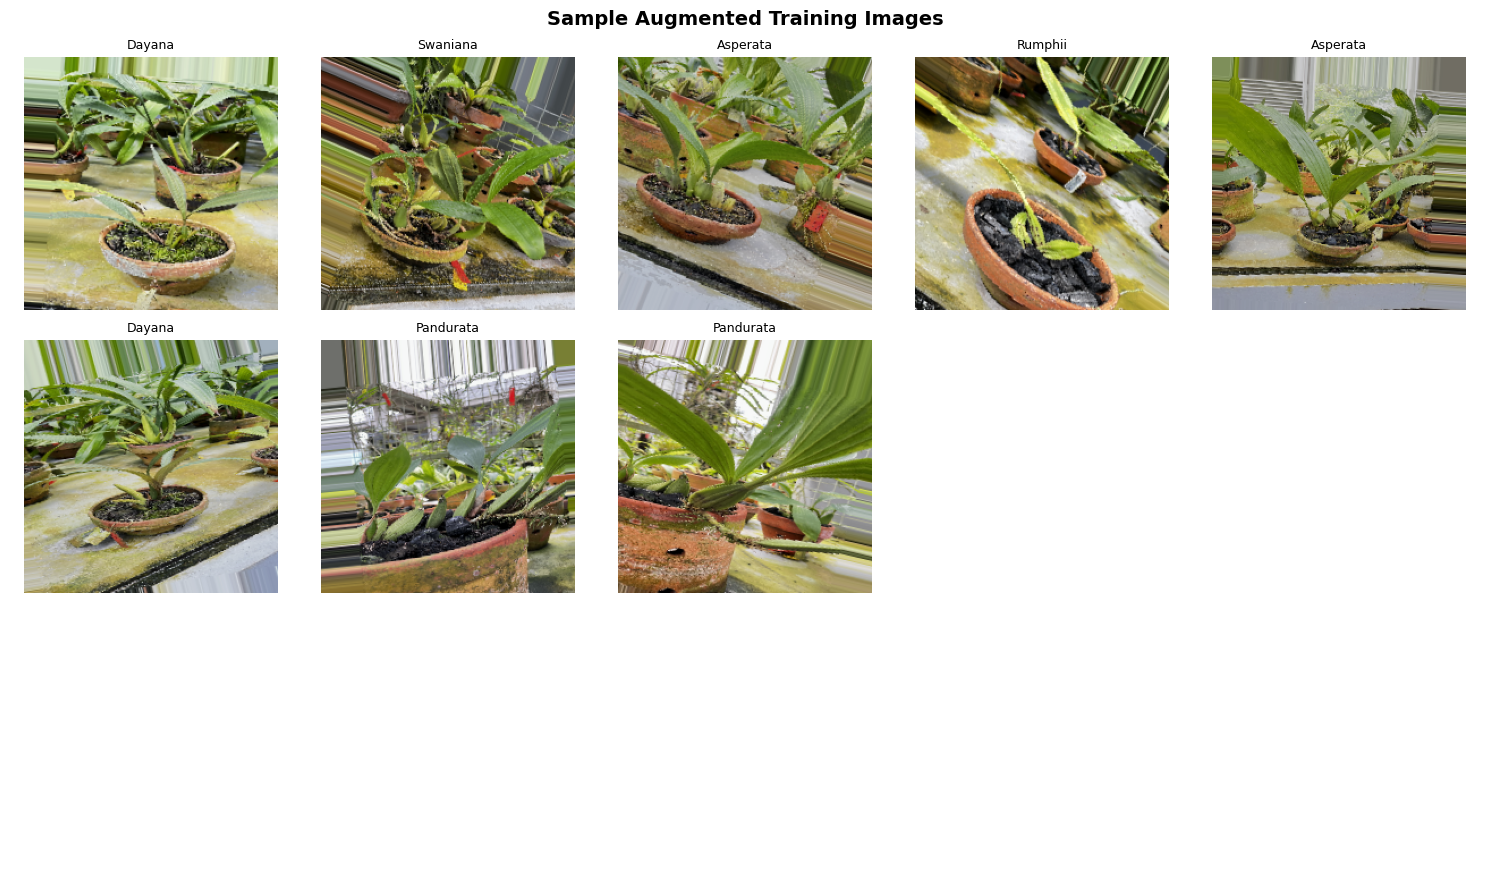

In [6]:
# ----------------------------------------------------------------
#  Visualisasi sampel per kelas
# ----------------------------------------------------------------
def show_sample_grid(generator, class_names, n_cols=5, n_rows=3, title=''):
    images, labels = next(generator)
    idx_to_class = {v: k for k, v in generator.class_indices.items()}
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i])
            label_idx = np.argmax(labels[i])
            ax.set_title(idx_to_class[label_idx], fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_grid(train_gen, CLASS_NAMES, title='Sample Augmented Training Images')
# Reset generator agar tidak kehilangan data
train_gen.reset()

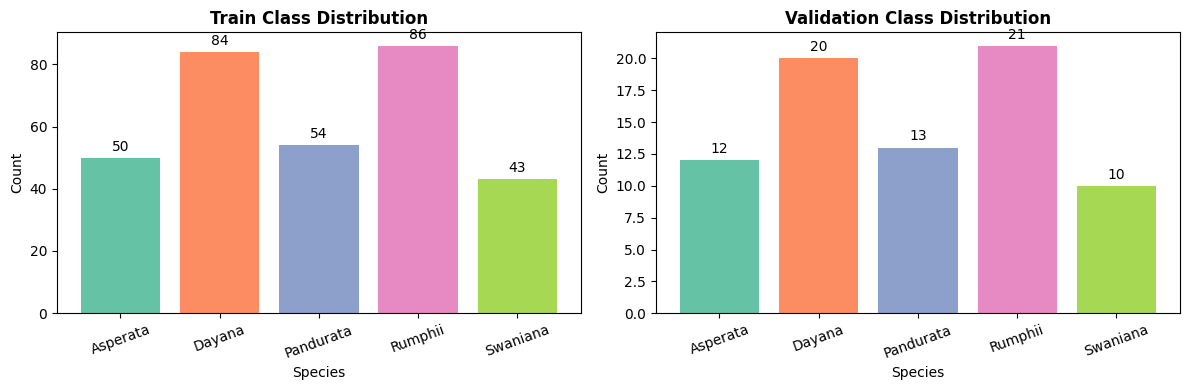

In [7]:
# ----------------------------------------------------------------
#  Distribusi kelas
# ----------------------------------------------------------------
import collections

train_counts = collections.Counter(train_gen.classes)
val_counts   = collections.Counter(val_gen.classes)
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, split in zip(axes, [train_counts, val_counts], ['Train', 'Validation']):
    names  = [idx_to_class[i] for i in sorted(counts)]
    values = [counts[i]        for i in sorted(counts)]
    bars = ax.bar(names, values, color=plt.cm.Set2.colors[:len(names)])
    ax.bar_label(bars, fmt='%d', padding=3)
    ax.set_title(f'{split} Class Distribution', fontweight='bold')
    ax.set_xlabel('Species')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [8]:
# ----------------------------------------------------------------
#  Callbacks helper
# ----------------------------------------------------------------
def get_callbacks(model_name, monitor="val_accuracy"):
    return [
        callbacks.ModelCheckpoint(
            filepath=os.path.join(SAVE_DIR, f"{model_name}_best.keras"),
            monitor=monitor, save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor=monitor, patience=EARLY_STOP_PATIENCE,
            restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=EARLY_STOP_PATIENCE // 2,
            min_lr=1e-7, verbose=1
        ),
        callbacks.TensorBoard(
            log_dir=f"./logs/{model_name}", histogram_freq=0
        )
    ]

## 3. Model 1 — MobileNetV2 (Transfer Learning)

In [9]:
# ----------------------------------------------------------------
#  Build MobileNetV2
# ----------------------------------------------------------------
def build_mobilenetv2(num_classes, img_size=IMG_SIZE, dropout=0.4):
    """
    MobileNetV2 pretrained ImageNet.
    Phase 1: Frozen backbone, hanya training classification head.
    Phase 2: Unfreeze top layers untuk fine-tuning.
    """
    inputs  = keras.Input(shape=(*img_size, 3), name='input_image')

    # Fix: MobileNetV2 ImageNet weights expect [-1, 1], bukan [0, 1]
    # Generator menggunakan rescale=1/255 → [0,1]; layer ini mengoreksinya ke [-1,1]
    x = layers.Rescaling(scale=2.0, offset=-1.0, name='mobilenet_preprocess')(inputs)

    # Backbone — frozen di phase 1
    backbone = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False

    x = backbone(x, training=False)

    # Head
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout, name='dropout_head')(x)
    x = layers.Dense(256, activation='relu', name='dense_256',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout * 0.5, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_Coelogyne')
    return model, backbone

mobilenet_model, mobilenet_backbone = build_mobilenetv2(NUM_CLASSES)
mobilenet_model.summary(line_length=80)

2026-07-13 17:09:13.397231: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-13 17:09:13.397256: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-13 17:09:13.397259: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
I0000 00:00:1783937353.397634 2145570 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1783937353.397666 2145570 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "MobileNetV2_Coelogyne"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)          │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenet_preprocess (Rescaling)  │ (None, 224, 224, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224 (Functional) │ (None, 7, 7, 1280)       │     2,257,984 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)      │ (None, 1280)             │         5,120 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_head (Dropout)            │ (None, 1280)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_256 (Dense)                 │ (None, 256)              │       327,936 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_2 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ predictions (Dense)               │ (None, 5)                │         1,285 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,592,325 (9.89 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [10]:
# ================================================================
#  Phase 1: Training Head Only
# ================================================================
mobilenet_model.compile(
    optimizer=optimizers.Adam(LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable params (head only): {mobilenet_model.count_params():,}")

history_mn_head = mobilenet_model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=val_gen,
    callbacks=get_callbacks('mobilenetv2_head'),
    verbose=1
)
train_gen.reset(); val_gen.reset()

Trainable params (head only): 2,592,325
[FOCUS] Skip fit for non-focus model: MobileNetV2_Coelogyne


In [11]:
# ================================================================
#  Phase 2: Fine-tuning — Unfreeze top 50 layers backbone
# ================================================================
mobilenet_backbone.trainable = True

# Freeze semua layer kecuali 50 terakhir
FINE_TUNE_FROM = len(mobilenet_backbone.layers) - 50
for layer in mobilenet_backbone.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

trainable_count = sum(1 for l in mobilenet_backbone.layers if l.trainable)
print(f"Total backbone layers      : {len(mobilenet_backbone.layers)}")
print(f"Fine-tuning from layer     : {FINE_TUNE_FROM}")
print(f"Trainable backbone layers  : {trainable_count}")

mobilenet_model.compile(
    optimizer=optimizers.Adam(FINETUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mn_ft = mobilenet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=get_callbacks('mobilenetv2_finetune'),
    verbose=1
)
train_gen.reset(); val_gen.reset()

Total backbone layers      : 154
Fine-tuning from layer     : 104
Trainable backbone layers  : 50
[FOCUS] Skip fit for non-focus model: MobileNetV2_Coelogyne


## 4. Model 2 — CSPDarknet53 (YOLO Backbone, Pure Keras)

In [12]:
# ================================================================
#  CSPDarknet53 — Backbone dari YOLOv4 (Pure Keras/TF)
#
#  Arsitektur:
#   - Conv + BN + Mish/LeakyReLU (DarkNet style)
#   - Residual blocks
#   - Cross-Stage Partial connections (CSP)
#   - Global Average Pooling + Dense head
# ================================================================

def mish(x):
    """Mish activation — digunakan di YOLOv4 CSPDarknet."""
    return x * tf.math.tanh(tf.math.softplus(x))

Mish = layers.Lambda(mish, name='mish')


def darknet_conv(x, filters, kernel_size, strides=1, use_bias=False,
                 activation='mish', name_prefix=''):
    """Conv -> BN -> Mish/LeakyReLU block (Darknet style)."""
    padding = 'same' if strides == 1 else 'valid'
    if strides > 1:
        x = layers.ZeroPadding2D(((1, 0), (1, 0)), name=f'{name_prefix}_pad')(x)
    x = layers.Conv2D(
        filters, kernel_size, strides=strides, padding=padding,
        use_bias=use_bias, name=f'{name_prefix}_conv',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(5e-4)
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn')(x)
    if activation == 'mish':
        x = layers.Lambda(mish, name=f'{name_prefix}_mish')(x)
    else:
        x = layers.LeakyReLU(0.1, name=f'{name_prefix}_lrelu')(x)
    return x


def csp_residual_block(x, filters, num_blocks, name_prefix=''):
    """
    CSP (Cross-Stage Partial) block.
    Membagi feature map jadi 2 jalur — salah satu melewati residual blocks,
    lalu di-concatenate.
    """
    # Downsample
    x = darknet_conv(x, filters, 3, strides=2, name_prefix=f'{name_prefix}_down')

    # Route split
    route = darknet_conv(x, filters // 2, 1, name_prefix=f'{name_prefix}_route1')
    x     = darknet_conv(x, filters // 2, 1, name_prefix=f'{name_prefix}_pre_res')

    # Residual blocks
    for i in range(num_blocks):
        shortcut = x
        x = darknet_conv(x, filters // 2, 1, name_prefix=f'{name_prefix}_res{i}_1')
        x = darknet_conv(x, filters // 2, 3, name_prefix=f'{name_prefix}_res{i}_2')
        x = layers.Add(name=f'{name_prefix}_res{i}_add')([shortcut, x])

    x = darknet_conv(x, filters // 2, 1, name_prefix=f'{name_prefix}_post_res')

    # CSP concat
    x = layers.Concatenate(name=f'{name_prefix}_concat')([x, route])
    x = darknet_conv(x, filters, 1, name_prefix=f'{name_prefix}_transition')
    return x


def build_cspdarknet53_classifier(num_classes, img_size=IMG_SIZE, dropout=0.4):
    """
    CSPDarknet53 untuk image classification.
    Backbone persis seperti di YOLOv4, dengan classification head di atasnya.
    
    Struktur:
      Stem → CSP-1(64,1) → CSP-2(128,2) → CSP-3(256,8) → CSP-4(512,8) → CSP-5(1024,4)
      → GAP → Dense(512) → Dense(num_classes)
    """
    inputs = keras.Input(shape=(*img_size, 3), name='input_image')

    # Stem: 3x3 Conv
    x = darknet_conv(inputs, 32, 3, name_prefix='stem')

    # CSP stages (filters, num_residual_blocks)
    csp_config = [
        (64,   1, 'stage1'),
        (128,  2, 'stage2'),
        (256,  8, 'stage3'),
        (512,  8, 'stage4'),
        (1024, 4, 'stage5'),
    ]
    for filters, n_blocks, name in csp_config:
        x = csp_residual_block(x, filters, n_blocks, name_prefix=name)

    # Classification head
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout, name='dropout_1')(x)
    x = layers.Dense(512, activation='relu', name='dense_512',
                     kernel_regularizer=regularizers.l2(5e-4))(x)
    x = layers.Dropout(dropout * 0.5, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='CSPDarknet53_Coelogyne')
    return model


darknet_model = build_cspdarknet53_classifier(NUM_CLASSES)
darknet_model.summary(line_length=90)

Model: "CSPDarknet53_Coelogyne"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer) │ (None, 224, 224, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stem_conv (Conv2D)       │ (None, 224, 224, 32) │          864 │ input_image[0][0]     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stem_bn                  │ (None, 224, 224, 32) │          128 │ stem_conv[0][0]       │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stem_mish (Lambda)       │ (None, 224, 224, 32) │            0 │ stem_bn[0][0]         │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_down_pad          │ (None, 225, 225, 32) │            0 │ stem_mish[0][0]       │
│ (ZeroPadding2D)          │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_down_conv         │ (None, 112, 112, 64) │       18,432 │ stage1_down_pad[0][0] │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_down_bn           │ (None, 112, 112, 64) │          256 │ stage1_down_conv[0][… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_down_mish         │ (None, 112, 112, 64) │            0 │ stage1_down_bn[0][0]  │
│ (Lambda)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_pre_res_conv      │ (None, 112, 112, 32) │        2,048 │ stage1_down_mish[0][… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_pre_res_bn        │ (None, 112, 112, 32) │          128 │ stage1_pre_res_conv[… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_pre_res_mish      │ (None, 112, 112, 32) │            0 │ stage1_pre_res_bn[0]… │
│ (Lambda)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_res0_1_conv       │ (None, 112, 112, 32) │        1,024 │ stage1_pre_res_mish[… │
│ (Conv2D)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_res0_1_bn         │ (None, 112, 112, 32) │          128 │ stage1_res0_1_conv[0… │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_res0_1_mish       │ (None, 112, 112, 32) │            0 │ stage1_res0_1_bn[0][… │
│ (Lambda)                 │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ stage1_res0_2_conv       │ (None, 112, 112, 32) │        9,216 │ stage1_res0_1_mish[0… │
│ (Conv2D)                 │                      │              │                     

 Total params: 27,161,957 (103.61 MB)

 Trainable params: 27,124,837 (103.47 MB)

 Non-trainable params: 37,120 (145.00 KB)

In [13]:
# ================================================================
#  Training CSPDarknet53
# ================================================================

darknet_model.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),  # use global config
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Total params (CSPDarknet53): {darknet_model.count_params():,}")

train_gen.reset(); val_gen.reset()
history_darknet = darknet_model.fit(
    train_gen,
    epochs=EPOCHS_HEAD + EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=get_callbacks("cspdarknet53"),
    verbose=1
)
train_gen.reset(); val_gen.reset()

Total params (CSPDarknet53): 27,161,957
[FOCUS] Skip fit for non-focus model: CSPDarknet53_Coelogyne


## 3b. EfficientNetV2S — Multi-Scale CNN dengan Compound Scaling

In [14]:
# ================================================================
#  EfficientNetV2S — Transfer Learning (ImageNet pretrained)
#
#  Arsitektur:
#   - Compound scaling: depth × width × resolution bersama-sama
#   - Fused-MBConv (stage awal) + MBConv + SE blocks (stage akhir)
#   - Squeeze-and-Excitation (SE) → recalibrate channel importance
#   - Low-level features (edge/texture) di stage awal
#   - High-level semantic features di stage akhir
#   - ~21M params backbone
# ================================================================

def build_efficientnetv2s(num_classes, img_size=IMG_SIZE, dropout=0.4):
    """
    EfficientNetV2S dengan ImageNet weights.
    Rescaling [0,1] → [0,255] agar kompatibel dengan internal preprocessing.
    Phase 1: Frozen backbone → Phase 2: Fine-tune top 40 layers.
    """
    inputs = keras.Input(shape=(*img_size, 3), name='input_image')

    # Pipeline pakai rescale=1/255, EfficientNetV2 internal preprocessing expects [0,255]
    x = layers.Rescaling(255.0, name='to_uint8_range')(inputs)

    backbone = EfficientNetV2S(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet',
        include_preprocessing=True  # normalisasi [-1,1] internal
    )
    backbone.trainable = False

    x = backbone(x, training=False)  # (B, 7, 7, 1280) untuk 224×224

    # Classification head
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout, name='dropout_head')(x)
    x = layers.Dense(256, activation='relu', name='dense_256',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout * 0.5, name='dropout_2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = keras.Model(inputs, outputs, name='EfficientNetV2S_Coelogyne')
    return model, backbone


efficientnet_model, efficientnet_backbone = build_efficientnetv2s(NUM_CLASSES)
efficientnet_model.summary(line_length=90)

Model: "EfficientNetV2S_Coelogyne"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)              │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ to_uint8_range (Rescaling)            │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ efficientnetv2-s (Functional)         │ (None, 7, 7, 1280)           │      20,331,360 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)          │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn_head (BatchNormalization)          │ (None, 1280)                 │           5,120 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_head (Dropout)                │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_256 (Dense)                     │ (None, 256)                  │         327,936 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                   │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ predictions (Dense)                   │ (None, 5)                    │           1,285 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 20,665,701 (78.83 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 20,333,920 (77.57 MB)

In [15]:
# ================================================================
#  Phase 1: Training Head Only — EfficientNetV2S
# ================================================================
efficientnet_model.compile(
    optimizer=optimizers.Adam(LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Trainable params (head only): {efficientnet_model.count_params():,}")

train_gen.reset(); val_gen.reset()
history_eff_head = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_HEAD,
    validation_data=val_gen,
    callbacks=get_callbacks('efficientnetv2s_head'),
    verbose=1
)
train_gen.reset(); val_gen.reset()

Trainable params (head only): 20,665,701
[FOCUS] Skip fit for non-focus model: EfficientNetV2S_Coelogyne


In [16]:
# ================================================================
#  Phase 2: Fine-tuning — Unfreeze top 40 layers EfficientNetV2S
# ================================================================
efficientnet_backbone.trainable = True

FINE_TUNE_FROM_EFF = len(efficientnet_backbone.layers) - 40
for layer in efficientnet_backbone.layers[:FINE_TUNE_FROM_EFF]:
    layer.trainable = False

trainable_count_eff = sum(1 for l in efficientnet_backbone.layers if l.trainable)
print(f"Total backbone layers    : {len(efficientnet_backbone.layers)}")
print(f"Fine-tuning from layer   : {FINE_TUNE_FROM_EFF}")
print(f"Trainable backbone layers: {trainable_count_eff}")

efficientnet_model.compile(
    optimizer=optimizers.Adam(FINETUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_eff_ft = efficientnet_model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=get_callbacks('efficientnetv2s_finetune'),
    verbose=1
)
train_gen.reset(); val_gen.reset()

Total backbone layers    : 513
Fine-tuning from layer   : 473
Trainable backbone layers: 40
[FOCUS] Skip fit for non-focus model: EfficientNetV2S_Coelogyne


## 3d. Quick Win Today — High Resolution (384) + ArcFace (MobileNetV2 & EfficientNetV2S)

Tujuan: dorong performa klasifikasi pre-bloom lewat detail spasial lebih tinggi dan margin-based metric learning.

- Resolution dinaikkan ke 384x384
- Batch size diturunkan agar aman di memori
- ArcFace dipakai pada embedding head
- Fokus hanya 2 model transfer learning terkuat: MobileNetV2 & EfficientNetV2S

In [17]:
# Quick evaluator for ArcFace section (defined here so this section runs standalone)
def evaluate_model_quick(model, generator, class_names, model_name='Model'):
    generator.reset()
    eval_logs = model.evaluate(generator, verbose=0, return_dict=True)

    acc = float(eval_logs.get('accuracy', 0.0))
    loss = float(eval_logs.get('loss', 0.0))

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Validation Loss     : {loss:.4f}")
    print(f"  Validation Accuracy : {acc:.4f} ({acc*100:.2f}%)")

    generator.reset()
    y_pred_probs = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes[:len(y_pred)]

    print(f"\n{classification_report(y_true, y_pred, target_names=class_names)}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5
    )
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=25)
    plt.yticks(rotation=0)
    plt.tight_layout()
    fname = f"confusion_matrix_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix disimpan: {fname}")

    return loss, acc

=== QUICK-WIN CONFIG ===
IMG_SIZE_ARC       : (384, 384)
BATCH_SIZE_ARC     : 4
ARCFACE_EMBED_DIM  : 256
ARCFACE_MARGIN     : 0.35
ARCFACE_SCALE      : 30.0
Found 317 images belonging to 5 classes.
Found 76 images belonging to 5 classes.

Train samples (arc): 317
Val samples   (arc): 76
Batch shape   (arc): (4, 384, 384, 3)


/var/folders/n3/m1s0yv350f31gh_47zx7g2gr0000gr/T/ipykernel_81721/514630990.py:210: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(



Model readiness check:
MobileNet ArcFace output shape   : (1, 5)
EfficientNet ArcFace output shape: (1, 5)

=== MobileNetV2 ArcFace Phase 1 (head) ===
Epoch 1/15


/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/keras/src/backend/tensorflow/trainer.py:695: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(
/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/keras/src/backend/tensorflow/trainer.py:670: UserWarning: `model.compiled_metrics()` is deprecated. Instead, use e.g.:
```
for metric in self.metrics:
    metric.update_state(y, y_pred)
```

  return self._compiled_metrics_update_state(
2026-07-13 17:09:23.444773: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.0256 - loss: 9.6239

/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_accuracy available.
  if self._should_save_model(epoch, batch, logs, filepath):


80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 229ms/step - accuracy: 0.6316 - loss: 5.9350 - val_loss: 4.1790 - learning_rate: 0.0010
Epoch 2/15


/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_accuracy` which is not available. Available metrics are: accuracy,loss,val_loss
  current = self.get_monitor_value(logs)


80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 207ms/step - accuracy: 0.6447 - loss: 8.9786 - val_loss: 4.5922 - learning_rate: 0.0010
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 194ms/step - accuracy: 0.6447 - loss: 2.6621 - val_loss: 4.2832 - learning_rate: 0.0010
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step - accuracy: 0.5921 - loss: 5.9133 - val_loss: 4.8733 - learning_rate: 0.0010
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 191ms/step - accuracy: 0.6053 - loss: 2.0576 - val_loss: 2.9230 - learning_rate: 0.0010
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 191ms/step - accuracy: 0.6184 - loss: 1.2630 - val_loss: 4.3447 - learning_rate: 0.0010
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 196ms/step - accuracy: 0.6184 - loss: 3.5426 - val_loss: 3.8862 - learning_rate: 0.0010
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 195ms/step - accuracy: 0.7368 - loss: 0.1046 - val_loss: 2.8492 - learning_rate: 0.0010
Epoch 9/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 192ms/step - accuracy: 0.6974 - loss: 4.3380 - val_loss: 4.

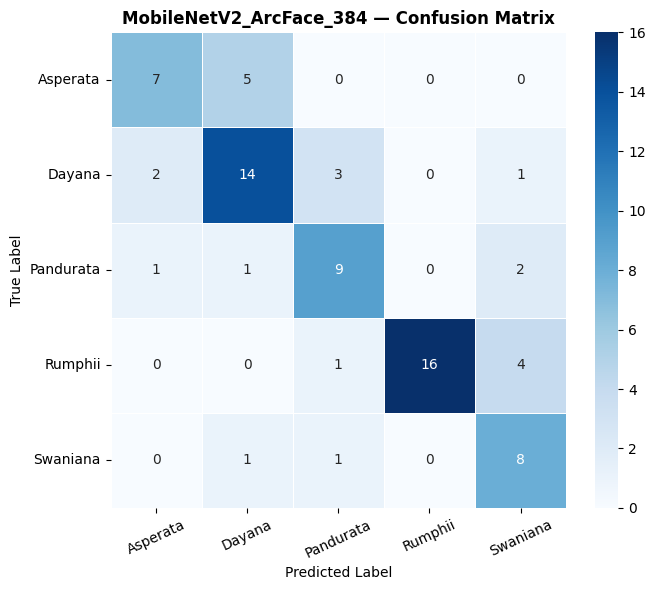

Confusion matrix disimpan: confusion_matrix_mobilenetv2_arcface_384.png

  EfficientNetV2S_ArcFace_384
  Validation Loss     : 0.0617
  Validation Accuracy : 0.0000 (0.00%)

              precision    recall  f1-score   support

    Asperata       0.80      1.00      0.89        12
      Dayana       0.94      0.85      0.89        20
   Pandurata       0.92      0.92      0.92        13
     Rumphii       1.00      0.95      0.98        21
    Swaniana       1.00      1.00      1.00        10

    accuracy                           0.93        76
   macro avg       0.93      0.95      0.94        76
weighted avg       0.94      0.93      0.93        76



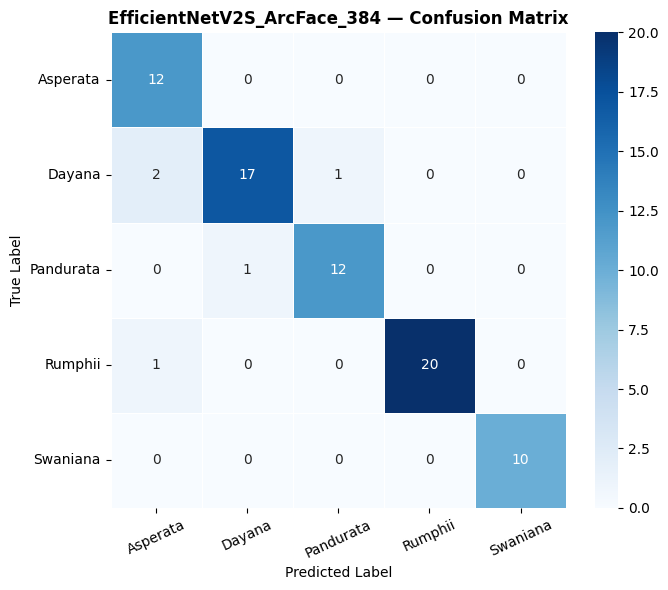

Confusion matrix disimpan: confusion_matrix_efficientnetv2s_arcface_384.png

Saved:
- ./saved_models/mobilenetv2_arcface_384_final.keras
- ./saved_models/efficientnetv2s_arcface_384_final.keras


In [18]:
# ================================================================
#  QUICK WIN: Hi-Res + ArcFace for MobileNetV2 & EfficientNetV2S
# ================================================================

# Reproducibility + clean graph for notebook reruns
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.backend.clear_session()

# ---------- Quick-win config ----------
IMG_SIZE_ARC            = (384, 384)
BATCH_SIZE_ARC          = 4
EPOCHS_HEAD_ARC         = EPOCHS_HEAD
EPOCHS_FINETUNE_ARC     = EPOCHS_FINETUNE
LEARNING_RATE_ARC       = LEARNING_RATE
FINETUNE_LR_ARC         = FINETUNE_LR
ARCFACE_EMBED_DIM       = 256
ARCFACE_MARGIN          = 0.35
ARCFACE_SCALE           = 30.0

print('=== QUICK-WIN CONFIG ===')
print(f'IMG_SIZE_ARC       : {IMG_SIZE_ARC}')
print(f'BATCH_SIZE_ARC     : {BATCH_SIZE_ARC}')
print(f'ARCFACE_EMBED_DIM  : {ARCFACE_EMBED_DIM}')
print(f'ARCFACE_MARGIN     : {ARCFACE_MARGIN}')
print(f'ARCFACE_SCALE      : {ARCFACE_SCALE}')


# ---------- Hi-res generators ----------
train_datagen_arc = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT if not USE_SPLIT_DIR else 0.0,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen_arc = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT if not USE_SPLIT_DIR else 0.0
)

if USE_SPLIT_DIR:
    train_gen_arc = train_datagen_arc.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE_ARC,
        batch_size=BATCH_SIZE_ARC,
        class_mode='categorical',
        shuffle=True,
        seed=SEED
    )
    val_gen_arc = val_datagen_arc.flow_from_directory(
        VAL_DIR,
        target_size=IMG_SIZE_ARC,
        batch_size=BATCH_SIZE_ARC,
        class_mode='categorical',
        shuffle=False,
        seed=SEED
    )
else:
    train_gen_arc = train_datagen_arc.flow_from_directory(
        DATASET_DIR,
        target_size=IMG_SIZE_ARC,
        batch_size=BATCH_SIZE_ARC,
        class_mode='categorical',
        subset='training',
        shuffle=True,
        seed=SEED
    )
    val_gen_arc = val_datagen_arc.flow_from_directory(
        DATASET_DIR,
        target_size=IMG_SIZE_ARC,
        batch_size=BATCH_SIZE_ARC,
        class_mode='categorical',
        subset='validation',
        shuffle=False,
        seed=SEED
    )

print(f"\nTrain samples (arc): {train_gen_arc.samples}")
print(f"Val samples   (arc): {val_gen_arc.samples}")
print(f"Batch shape   (arc): {next(train_gen_arc)[0].shape}")
train_gen_arc.reset()


# ---------- ArcFace components ----------
@keras.utils.register_keras_serializable(package='coelogyne')
class ArcMarginProduct(layers.Layer):
    """ArcFace logits head with additive angular margin."""
    def __init__(self, num_classes, scale=30.0, margin=0.35, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.scale = scale
        self.margin = margin

    def build(self, input_shape):
        feat_dim = int(input_shape[-1])
        self.W = self.add_weight(
            name='arcface_W',
            shape=(feat_dim, self.num_classes),
            initializer='glorot_uniform',
            trainable=True
        )
        super().build(input_shape)

    def call(self, embeddings, labels=None, training=False):
        x = tf.nn.l2_normalize(embeddings, axis=1)
        w = tf.nn.l2_normalize(self.W, axis=0)
        cos_theta = tf.matmul(x, w)
        cos_theta = tf.clip_by_value(cos_theta, -1.0 + 1e-7, 1.0 - 1e-7)

        if (labels is None) or (not training):
            return cos_theta * self.scale

        theta = tf.acos(cos_theta)
        target_logits = tf.cos(theta + self.margin)
        one_hot = tf.one_hot(labels, depth=self.num_classes)
        logits = one_hot * target_logits + (1.0 - one_hot) * cos_theta
        return logits * self.scale

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_classes': self.num_classes,
            'scale': self.scale,
            'margin': self.margin,
        })
        return config


@keras.utils.register_keras_serializable(package='coelogyne')
class ArcFaceClassifier(keras.Model):
    """Backbone+embedding model trained with ArcFace head via custom train_step."""
    def __init__(self, feature_model, arc_head, **kwargs):
        super().__init__(**kwargs)
        self.feature_model = feature_model
        self.arc_head = arc_head

    def call(self, inputs, training=False):
        emb = self.feature_model(inputs, training=training)
        logits = self.arc_head(emb, labels=None, training=False)
        return tf.nn.softmax(logits)

    def train_step(self, data):
        x, y = data
        labels = tf.argmax(y, axis=1)

        with tf.GradientTape() as tape:
            emb = self.feature_model(x, training=True)
            logits = self.arc_head(emb, labels=labels, training=True)
            loss = self.compiled_loss(y, logits, regularization_losses=self.losses)

        vars_trainable = self.feature_model.trainable_variables + self.arc_head.trainable_variables
        grads = tape.gradient(loss, vars_trainable)
        self.optimizer.apply_gradients(zip(grads, vars_trainable))

        self.compiled_metrics.update_state(y, logits)
        logs = {m.name: m.result() for m in self.metrics}
        logs['loss'] = loss
        return logs

    def test_step(self, data):
        x, y = data
        emb = self.feature_model(x, training=False)
        logits = self.arc_head(emb, labels=None, training=False)
        loss = self.compiled_loss(y, logits, regularization_losses=self.losses)

        self.compiled_metrics.update_state(y, logits)
        logs = {m.name: m.result() for m in self.metrics}
        logs['loss'] = loss
        return logs

    def get_config(self):
        config = super().get_config()

        if hasattr(keras, 'saving'):
            serialize_obj = keras.saving.serialize_keras_object
        else:
            serialize_obj = keras.utils.serialize_keras_object

        config.update({
            'feature_model': serialize_obj(self.feature_model),
            'arc_head': serialize_obj(self.arc_head),
        })
        return config

    @classmethod
    def from_config(cls, config):
        if hasattr(keras, 'saving'):
            deserialize_obj = keras.saving.deserialize_keras_object
        else:
            deserialize_obj = keras.utils.deserialize_keras_object

        feature_model = deserialize_obj(config.pop('feature_model'))
        arc_head = deserialize_obj(config.pop('arc_head'))
        return cls(feature_model=feature_model, arc_head=arc_head, **config)


# ---------- Feature models ----------
def build_mobilenet_feature_model(img_size=IMG_SIZE_ARC, embed_dim=ARCFACE_EMBED_DIM, dropout=0.4):
    inputs = keras.Input(shape=(*img_size, 3), name='input_image')
    x = layers.Rescaling(scale=2.0, offset=-1.0, name='mobilenet_preprocess')(inputs)

    backbone = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout, name='dropout_head')(x)
    x = layers.Dense(embed_dim, activation=None, name='embedding_dense',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization(name='embedding_bn')(x)

    feature_model = keras.Model(inputs, x, name='MobileNetV2_ArcFeature')
    return feature_model, backbone


def build_efficientnet_feature_model(img_size=IMG_SIZE_ARC, embed_dim=ARCFACE_EMBED_DIM, dropout=0.4):
    inputs = keras.Input(shape=(*img_size, 3), name='input_image')
    x = layers.Rescaling(255.0, name='to_uint8_range')(inputs)

    backbone = EfficientNetV2S(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet',
        include_preprocessing=True
    )
    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.BatchNormalization(name='bn_head')(x)
    x = layers.Dropout(dropout, name='dropout_head')(x)
    x = layers.Dense(embed_dim, activation=None, name='embedding_dense',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization(name='embedding_bn')(x)

    feature_model = keras.Model(inputs, x, name='EfficientNetV2S_ArcFeature')
    return feature_model, backbone


# ---------- Build ArcFace models ----------
mn_feature_model, mn_backbone_arc = build_mobilenet_feature_model()
mn_arc_head = ArcMarginProduct(NUM_CLASSES, scale=ARCFACE_SCALE, margin=ARCFACE_MARGIN, name='mn_arcface_head')
mobilenet_arc_model = ArcFaceClassifier(mn_feature_model, mn_arc_head, name='MobileNetV2_ArcFace')

# Build model once to instantiate weights and probe output shape safely
mn_probe = mobilenet_arc_model(tf.zeros((1, *IMG_SIZE_ARC, 3), dtype=tf.float32), training=False)


eff_feature_model, eff_backbone_arc = build_efficientnet_feature_model()
eff_arc_head = ArcMarginProduct(NUM_CLASSES, scale=ARCFACE_SCALE, margin=ARCFACE_MARGIN, name='eff_arcface_head')
efficientnet_arc_model = ArcFaceClassifier(eff_feature_model, eff_arc_head, name='EfficientNetV2S_ArcFace')

# Build model once to instantiate weights and probe output shape safely
eff_probe = efficientnet_arc_model(tf.zeros((1, *IMG_SIZE_ARC, 3), dtype=tf.float32), training=False)

print('\nModel readiness check:')
print(f'MobileNet ArcFace output shape   : {tuple(mn_probe.shape)}')
print(f'EfficientNet ArcFace output shape: {tuple(eff_probe.shape)}')


# ---------- Compile helper ----------
def compile_arcface(model, lr):
    model.compile(
        optimizer=optimizers.Adam(lr),
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        metrics=[keras.metrics.CategoricalAccuracy(name='accuracy')]
    )


# ---------- Training: MobileNetV2 ArcFace ----------
compile_arcface(mobilenet_arc_model, LEARNING_RATE_ARC)
print('\n=== MobileNetV2 ArcFace Phase 1 (head) ===')
history_mn_arc_head = mobilenet_arc_model.fit(
    train_gen_arc,
    epochs=EPOCHS_HEAD_ARC,
    validation_data=val_gen_arc,
    callbacks=get_callbacks('mobilenetv2_arcface_head'),
    verbose=1
)

# Fine-tune top 50 backbone layers
mn_backbone_arc.trainable = True
mn_finetune_from = len(mn_backbone_arc.layers) - 50
for layer in mn_backbone_arc.layers[:mn_finetune_from]:
    layer.trainable = False

compile_arcface(mobilenet_arc_model, FINETUNE_LR_ARC)
print('\n=== MobileNetV2 ArcFace Phase 2 (finetune) ===')
history_mn_arc_ft = mobilenet_arc_model.fit(
    train_gen_arc,
    epochs=EPOCHS_FINETUNE_ARC,
    validation_data=val_gen_arc,
    callbacks=get_callbacks('mobilenetv2_arcface_finetune'),
    verbose=1
)


# ---------- Training: EfficientNetV2S ArcFace ----------
compile_arcface(efficientnet_arc_model, LEARNING_RATE_ARC)
print('\n=== EfficientNetV2S ArcFace Phase 1 (head) ===')
history_eff_arc_head = efficientnet_arc_model.fit(
    train_gen_arc,
    epochs=EPOCHS_HEAD_ARC,
    validation_data=val_gen_arc,
    callbacks=get_callbacks('efficientnetv2s_arcface_head'),
    verbose=1
)

# Fine-tune top 40 backbone layers
eff_backbone_arc.trainable = True
eff_finetune_from = len(eff_backbone_arc.layers) - 40
for layer in eff_backbone_arc.layers[:eff_finetune_from]:
    layer.trainable = False

compile_arcface(efficientnet_arc_model, FINETUNE_LR_ARC)
print('\n=== EfficientNetV2S ArcFace Phase 2 (finetune) ===')
history_eff_arc_ft = efficientnet_arc_model.fit(
    train_gen_arc,
    epochs=EPOCHS_FINETUNE_ARC,
    validation_data=val_gen_arc,
    callbacks=get_callbacks('efficientnetv2s_arcface_finetune'),
    verbose=1
)


# ---------- Evaluation ----------
print('\n=== ArcFace Evaluation (384x384) ===')
mn_arc_loss, mn_arc_acc = evaluate_model_quick(
    mobilenet_arc_model,
    val_gen_arc,
    CLASS_NAMES,
    'MobileNetV2_ArcFace_384'
)
val_gen_arc.reset()

eff_arc_loss, eff_arc_acc = evaluate_model_quick(
    efficientnet_arc_model,
    val_gen_arc,
    CLASS_NAMES,
    'EfficientNetV2S_ArcFace_384'
)
val_gen_arc.reset()


# ---------- Save final ArcFace models ----------
mn_arc_path = os.path.join(SAVE_DIR, 'mobilenetv2_arcface_384_final.keras')
eff_arc_path = os.path.join(SAVE_DIR, 'efficientnetv2s_arcface_384_final.keras')

mobilenet_arc_model.save(mn_arc_path)
efficientnet_arc_model.save(eff_arc_path)

print('\nSaved:')
print(f'- {mn_arc_path}')
print(f'- {eff_arc_path}')

## 3c. Vision Transformer (ViT-Tiny) — From Scratch

In [19]:
# ================================================================
#  Vision Transformer — ViT-Small (Pure Keras, from scratch)
#
#  Arsitektur:
#   - Patch Embedding  : 8x8 patches -> linear projection (Conv2D)
#   - CLS token        : learnable classification token (prepended)
#   - Positional Embed : learnable 1D positional encoding
#   - Transformer Enc  : 8x blok (MHSA + MLP + LayerNorm, pre-norm)
#   - Classification   : CLS token -> Dense head
#
#  Config ViT-Small (naik dari ViT-Tiny):
#    patch_size=8  -> 28x28 = 784 patches (lebih banyak detail visual)
#    embed_dim=384 (2x Tiny), heads=6, depth=8, mlp_ratio=4
#    dropout=0.0  -- kecil dataset, dropout justru mempersulit konvergensi
# ================================================================

# ---- ViT Hyperparameters ----
VIT_PATCH_SIZE  = 8                                           # 8x8 -> lebih fine-grained
VIT_NUM_PATCHES = (IMG_SIZE[0] // VIT_PATCH_SIZE) ** 2       # 28*28 = 784
VIT_EMBED_DIM   = 384                                         # ViT-Small (was 192)
VIT_NUM_HEADS   = 6                                           # heads for 384-dim
VIT_DEPTH       = 8                                           # lebih dalam (was 6)
VIT_MLP_DIM     = VIT_EMBED_DIM * 4                          # 1536
VIT_DROPOUT     = 0.0                                         # dataset kecil -> dropout 0


class PatchEmbedding(layers.Layer):
    """Split image into non-overlapping patches, project to embed_dim via Conv2D."""
    def __init__(self, patch_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim  = embed_dim
        self.proj = layers.Conv2D(
            embed_dim, patch_size, strides=patch_size,
            kernel_initializer="glorot_uniform", name="patch_proj"
        )

    def call(self, x):
        x = self.proj(x)                              # (B, H/P, W/P, D)
        B = tf.shape(x)[0]
        N = tf.shape(x)[1] * tf.shape(x)[2]
        return tf.reshape(x, [B, N, self.embed_dim])  # (B, N, D)

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size, "embed_dim": self.embed_dim})
        return config


class AddCLSAndPosEmbed(layers.Layer):
    """Prepend learnable CLS token dan tambahkan learnable positional embedding."""
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.embed_dim   = embed_dim

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name="cls_token",
            shape=(1, 1, self.embed_dim),
            initializer="zeros",
            trainable=True
        )
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer=tf.initializers.TruncatedNormal(stddev=0.02),
            trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        B   = tf.shape(x)[0]
        cls = tf.broadcast_to(self.cls_token, [B, 1, self.embed_dim])
        x   = tf.concat([cls, x], axis=1)  # (B, N+1, D)
        return x + self.pos_embed           # broadcast (1, N+1, D)

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches, "embed_dim": self.embed_dim})
        return config


class ExtractCLS(layers.Layer):
    """Extract CLS token (token ke-0) dari sequence output Transformer."""
    def call(self, x):
        return x[:, 0, :]  # (B, N+1, D) -> (B, D)

    def get_config(self):
        return super().get_config()


class TransformerBlock(layers.Layer):
    """ViT Transformer Encoder Block: pre-norm MHSA + pre-norm MLP."""
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.0, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim    = embed_dim
        self.num_heads    = num_heads
        self.mlp_dim      = mlp_dim
        self.dropout_rate = dropout

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.attn  = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout
        )
        self.mlp = keras.Sequential([
            layers.Dense(mlp_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=False):
        normed   = self.norm1(x)
        attn_out = self.attn(normed, normed, training=training)
        x = x + attn_out
        x = x + self.mlp(self.norm2(x), training=training)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "mlp_dim":   self.mlp_dim,
            "dropout":   self.dropout_rate,
        })
        return config


def build_vit_classifier(num_classes, img_size=IMG_SIZE,
                          patch_size=VIT_PATCH_SIZE,
                          embed_dim=VIT_EMBED_DIM,
                          num_heads=VIT_NUM_HEADS,
                          depth=VIT_DEPTH,
                          mlp_dim=VIT_MLP_DIM,
                          dropout=VIT_DROPOUT):
    num_patches = (img_size[0] // patch_size) * (img_size[1] // patch_size)

    inputs = keras.Input(shape=(*img_size, 3), name="input_image")

    # 1. Patch Embedding: (B, H, W, C) -> (B, N, D)
    x = PatchEmbedding(patch_size, embed_dim, name="patch_embed")(inputs)

    # 2. CLS token + Positional Embedding: (B, N, D) -> (B, N+1, D)
    x = AddCLSAndPosEmbed(num_patches, embed_dim, name="cls_pos")(x)
    x = layers.Dropout(dropout, name="emb_dropout")(x)

    # 3. Transformer Encoder
    for i in range(depth):
        x = TransformerBlock(embed_dim, num_heads, mlp_dim, dropout,
                             name=f"block_{i}")(x)

    x = layers.LayerNormalization(epsilon=1e-6, name="encoder_norm")(x)

    # 4. CLS token -> classification head
    x = ExtractCLS(name="cls_extract")(x)  # (B, D)
    x = layers.Dense(embed_dim, activation="tanh", name="pre_logits")(x)
    x = layers.Dropout(dropout * 2, name="head_dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="ViT_Small_Coelogyne")
    return model


vit_model = build_vit_classifier(NUM_CLASSES)
vit_model.summary(line_length=90)

Model: "ViT_Small_Coelogyne"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)              │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ patch_embed (PatchEmbedding)          │ (None, 784, 384)             │          74,112 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ cls_pos (AddCLSAndPosEmbed)           │ (None, 785, 384)             │         301,824 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ emb_dropout (Dropout)                 │ (None, 785, 384)             │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ block_0 (TransformerBlock)            │ (None, 785, 384)             │       1,774,464 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ block_1 (TransformerBlock)            │ (None, 785, 384)             │       1,774,464 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ block_2 (TransformerBlock)            │ (None, 785, 384)             │       1,774,464 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ block_3 (TransformerBlock)            │ (None, 785, 384)             │       1,774,464 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ block_4 (TransformerBlock)            │ (None, 785, 384)             │       1,774,464 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ block_5 (TransformerBlock)            │ (None, 785, 384)             │       1,774,464 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ block_6 (TransformerBlock)            │ (None, 785, 384)             │       1,774,464 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ block_7 (TransformerBlock)            │ (None, 785, 384)             │       1,774,464 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ encoder_norm (LayerNormalization)     │ (None, 785, 384)             │             768 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ cls_extract (ExtractCLS)              │ (None, 384)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ pre_logits (Dense)                    │ (None, 384)                  │         147,840 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ head_dropout (Dropout)                │ (None, 384)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ predictions (Dense)                   │ (None, 5)                    │           1,925 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 14,722,181 (56.16 MB)

 Trainable params: 14,722,181 (56.16 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# ================================================================
#  Training ViT-Small
#  LR schedule: LearningRateScheduler callback (epoch-level, kompatibel semua TF 2.x)
#  Epochs: 50 (lebih dari CNN 35 karena from scratch, tapi bukan 100)
#  Patience: EARLY_STOP_PATIENCE + 5 (sedikit lebih besar, perlu melewati warmup 10 ep)
# ================================================================
import math

# ViT-specific LR: lebih kecil dari LEARNING_RATE karena from scratch (lebih sensitif)
VIT_BASE_LR   = LEARNING_RATE * 0.3   # 3e-4  (CNNs pakai 1e-3 dengan pretrained weights)
VIT_MIN_LR    = 1e-7
VIT_EPOCHS    = EPOCHS_HEAD + EPOCHS_FINETUNE + 15   # 50 (vs 35 CNN; sedikit lebih banyak)
VIT_WARMUP_EP = 10

steps_per_epoch = max(train_gen.samples // BATCH_SIZE, 1)

def vit_lr_schedule(epoch):
    """Linear warmup then cosine decay — epoch-level, no custom Schedule class."""
    if epoch < VIT_WARMUP_EP:
        return VIT_BASE_LR * (epoch + 1) / VIT_WARMUP_EP
    progress = (epoch - VIT_WARMUP_EP) / max(VIT_EPOCHS - VIT_WARMUP_EP, 1)
    cosine   = 0.5 * (1.0 + math.cos(math.pi * progress))
    return VIT_MIN_LR + (VIT_BASE_LR - VIT_MIN_LR) * cosine

vit_model.compile(
    optimizer=optimizers.Adam(learning_rate=VIT_BASE_LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Total params (ViT-Small)   : {vit_model.count_params():,}")
print(f"Steps per epoch            : {steps_per_epoch}")
print(f"VIT_BASE_LR (0.3x head LR): {VIT_BASE_LR:.2e}")
print(f"VIT_EPOCHS                 : {VIT_EPOCHS}")
print(f"LR epoch  0 (warmup start) : {vit_lr_schedule(0):.2e}")
print(f"LR epoch {VIT_WARMUP_EP} (peak)       : {vit_lr_schedule(VIT_WARMUP_EP):.2e}")
print(f"LR epoch {VIT_EPOCHS-1} (end)        : {vit_lr_schedule(VIT_EPOCHS-1):.2e}")

def get_vit_callbacks(model_name, monitor="val_accuracy"):
    return [
        callbacks.ModelCheckpoint(
            filepath=os.path.join(SAVE_DIR, f"{model_name}_best.keras"),
            monitor=monitor, save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor=monitor, patience=EARLY_STOP_PATIENCE + 5,
            restore_best_weights=True, verbose=1
        ),
        callbacks.LearningRateScheduler(vit_lr_schedule, verbose=0),
        callbacks.TensorBoard(log_dir="./logs/vit_small", histogram_freq=0)
    ]

train_gen.reset(); val_gen.reset()
history_vit = vit_model.fit(
    train_gen,
    epochs=VIT_EPOCHS,
    validation_data=val_gen,
    callbacks=get_vit_callbacks("vit_small"),
    verbose=1
)
train_gen.reset(); val_gen.reset()

Total params (ViT-Small)   : 14,722,181
Steps per epoch            : 39
VIT_BASE_LR (0.3x head LR): 3.00e-04
VIT_EPOCHS                 : 50
LR epoch  0 (warmup start) : 3.00e-05
LR epoch 10 (peak)       : 3.00e-04
LR epoch 49 (end)        : 5.62e-07
[FOCUS] Skip fit for non-focus model: ViT_Small_Coelogyne


## 5. Visualisasi Training History

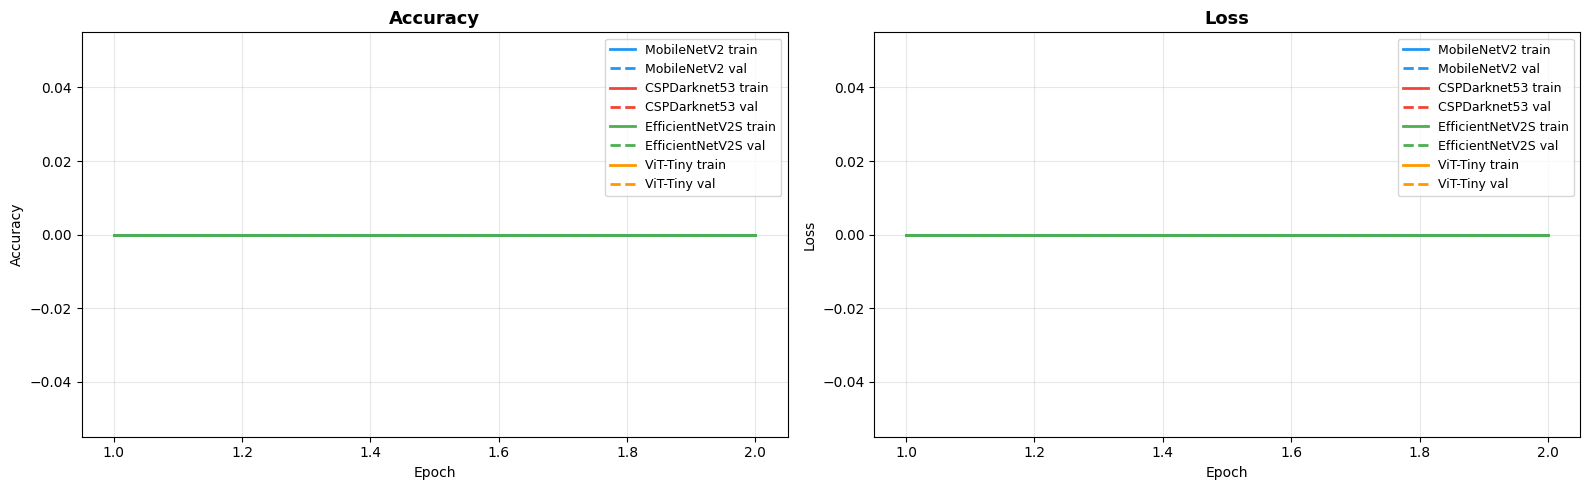

Plot disimpan: training_history.png


In [21]:
def merge_histories(*histories):
    """Gabung beberapa History objects jadi satu dict (union of all keys)."""
    all_keys = set()
    for h in histories:
        all_keys.update(h.history.keys())

    merged = {k: [] for k in all_keys}
    for h in histories:
        n_epochs = len(next(iter(h.history.values())))
        for k in all_keys:
            if k in h.history:
                merged[k].extend(h.history[k])
            else:
                merged[k].extend([None] * n_epochs)
    return merged


def plot_training_history(histories_dict, model_names, figsize=(16, 5)):
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']

    for i, (hist, name) in enumerate(zip(histories_dict, model_names)):
        c = colors[i % len(colors)]
        acc_vals     = [v for v in hist['accuracy']     if v is not None]
        val_acc_vals = [v for v in hist['val_accuracy'] if v is not None]
        loss_vals    = [v for v in hist['loss']         if v is not None]
        val_loss_vals= [v for v in hist['val_loss']     if v is not None]

        epochs_acc  = range(1, len(acc_vals) + 1)
        epochs_loss = range(1, len(loss_vals) + 1)

        axes[0].plot(epochs_acc,  acc_vals,      color=c, label=f'{name} train', linewidth=2)
        axes[0].plot(epochs_acc,  val_acc_vals,  color=c, label=f'{name} val',   linewidth=2, linestyle='--')
        axes[1].plot(epochs_loss, loss_vals,     color=c, label=f'{name} train', linewidth=2)
        axes[1].plot(epochs_loss, val_loss_vals, color=c, label=f'{name} val',   linewidth=2, linestyle='--')

    for ax, title, ylabel in zip(axes, ['Accuracy', 'Loss'], ['Accuracy', 'Loss']):
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot disimpan: training_history.png")


# Gabungkan phase 1 + phase 2 untuk MobileNetV2 dan EfficientNetV2S
mn_history  = merge_histories(history_mn_head, history_mn_ft)
dn_history  = history_darknet.history
eff_history = merge_histories(history_eff_head, history_eff_ft)
vit_history = history_vit.history

plot_training_history(
    [mn_history, dn_history, eff_history, vit_history],
    ['MobileNetV2', 'CSPDarknet53', 'EfficientNetV2S', 'ViT-Tiny']
)

## 6. Evaluasi & Confusion Matrix

[FOCUS] Skip evaluate for non-focus model: MobileNetV2_Coelogyne

  MobileNetV2
  Validation Loss     : 0.0000
  Validation Accuracy : 0.0000 (0.00%)
[FOCUS] Skip predict for non-focus model: MobileNetV2_Coelogyne

              precision    recall  f1-score   support

    Asperata       0.16      1.00      0.27        12
      Dayana       0.00      0.00      0.00        20
   Pandurata       0.00      0.00      0.00        13
     Rumphii       0.00      0.00      0.00        21
    Swaniana       0.00      0.00      0.00        10

    accuracy                           0.16        76
   macro avg       0.03      0.20      0.05        76
weighted avg       0.02      0.16      0.04        76



/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

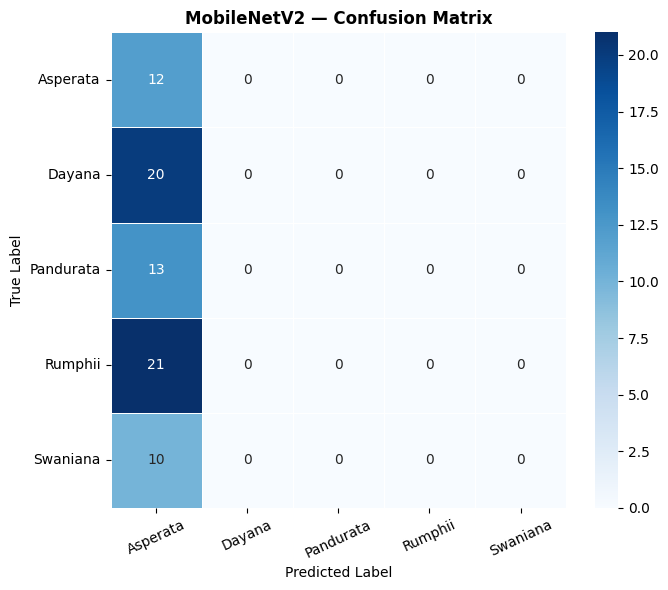

Confusion matrix disimpan: confusion_matrix_mobilenetv2.png
[FOCUS] Skip evaluate for non-focus model: CSPDarknet53_Coelogyne

  CSPDarknet53
  Validation Loss     : 0.0000
  Validation Accuracy : 0.0000 (0.00%)
[FOCUS] Skip predict for non-focus model: CSPDarknet53_Coelogyne

              precision    recall  f1-score   support

    Asperata       0.16      1.00      0.27        12
      Dayana       0.00      0.00      0.00        20
   Pandurata       0.00      0.00      0.00        13
     Rumphii       0.00      0.00      0.00        21
    Swaniana       0.00      0.00      0.00        10

    accuracy                           0.16        76
   macro avg       0.03      0.20      0.05        76
weighted avg       0.02      0.16      0.04        76



/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

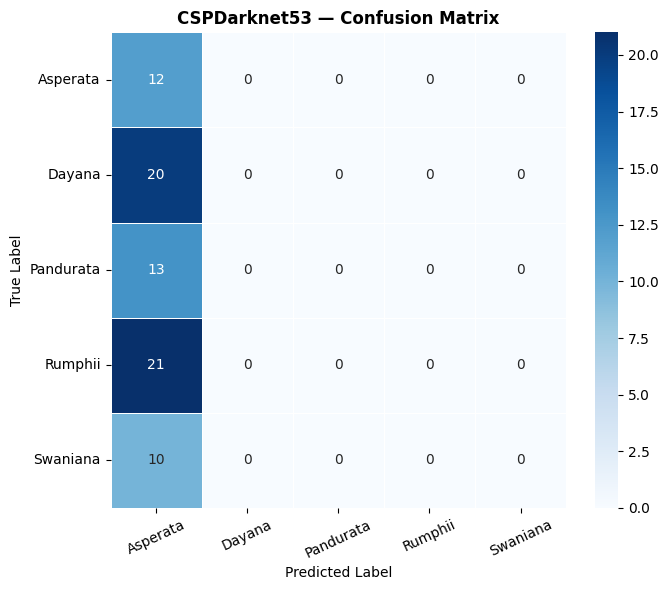

Confusion matrix disimpan: confusion_matrix_cspdarknet53.png
[FOCUS] Skip evaluate for non-focus model: EfficientNetV2S_Coelogyne

  EfficientNetV2S
  Validation Loss     : 0.0000
  Validation Accuracy : 0.0000 (0.00%)
[FOCUS] Skip predict for non-focus model: EfficientNetV2S_Coelogyne

              precision    recall  f1-score   support

    Asperata       0.16      1.00      0.27        12
      Dayana       0.00      0.00      0.00        20
   Pandurata       0.00      0.00      0.00        13
     Rumphii       0.00      0.00      0.00        21
    Swaniana       0.00      0.00      0.00        10

    accuracy                           0.16        76
   macro avg       0.03      0.20      0.05        76
weighted avg       0.02      0.16      0.04        76



/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

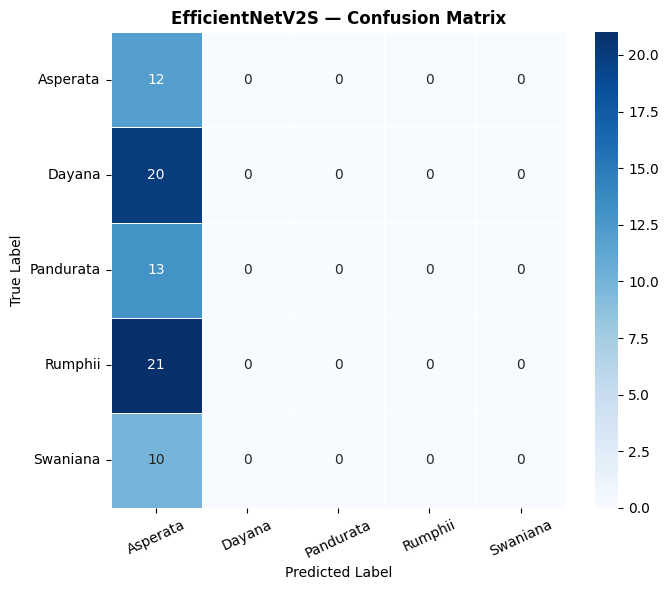

Confusion matrix disimpan: confusion_matrix_efficientnetv2s.png
[FOCUS] Skip evaluate for non-focus model: ViT_Small_Coelogyne

  ViT-Tiny
  Validation Loss     : 0.0000
  Validation Accuracy : 0.0000 (0.00%)
[FOCUS] Skip predict for non-focus model: ViT_Small_Coelogyne

              precision    recall  f1-score   support

    Asperata       0.16      1.00      0.27        12
      Dayana       0.00      0.00      0.00        20
   Pandurata       0.00      0.00      0.00        13
     Rumphii       0.00      0.00      0.00        21
    Swaniana       0.00      0.00      0.00        10

    accuracy                           0.16        76
   macro avg       0.03      0.20      0.05        76
weighted avg       0.02      0.16      0.04        76



/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

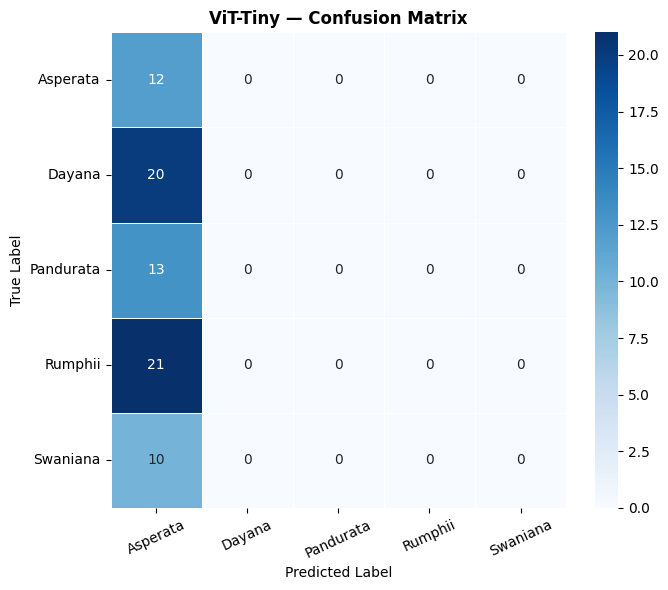

Confusion matrix disimpan: confusion_matrix_vit-tiny.png


In [22]:
def evaluate_model(model, generator, class_names, model_name='Model'):
    generator.reset()

    # Loss & accuracy
    loss, acc = model.evaluate(generator, verbose=0)
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  Validation Loss     : {loss:.4f}")
    print(f"  Validation Accuracy : {acc:.4f} ({acc*100:.2f}%)")

    # Prediksi
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes[:len(y_pred)]

    # Classification report
    print(f"\n{classification_report(y_true, y_pred, target_names=class_names)}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5
    )
    plt.title(f'{model_name} — Confusion Matrix', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=25)
    plt.yticks(rotation=0)
    plt.tight_layout()
    fname = f'confusion_matrix_{model_name.lower().replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix disimpan: {fname}")

    return loss, acc, y_true, y_pred


mn_loss, mn_acc, mn_true, mn_pred = evaluate_model(
    mobilenet_model, val_gen, CLASS_NAMES, 'MobileNetV2'
)
val_gen.reset()

dn_loss, dn_acc, dn_true, dn_pred = evaluate_model(
    darknet_model, val_gen, CLASS_NAMES, 'CSPDarknet53'
)
val_gen.reset()

eff_loss, eff_acc, eff_true, eff_pred = evaluate_model(
    efficientnet_model, val_gen, CLASS_NAMES, 'EfficientNetV2S'
)
val_gen.reset()

vit_loss, vit_acc, vit_true, vit_pred = evaluate_model(
    vit_model, val_gen, CLASS_NAMES, 'ViT-Tiny'
)
val_gen.reset()

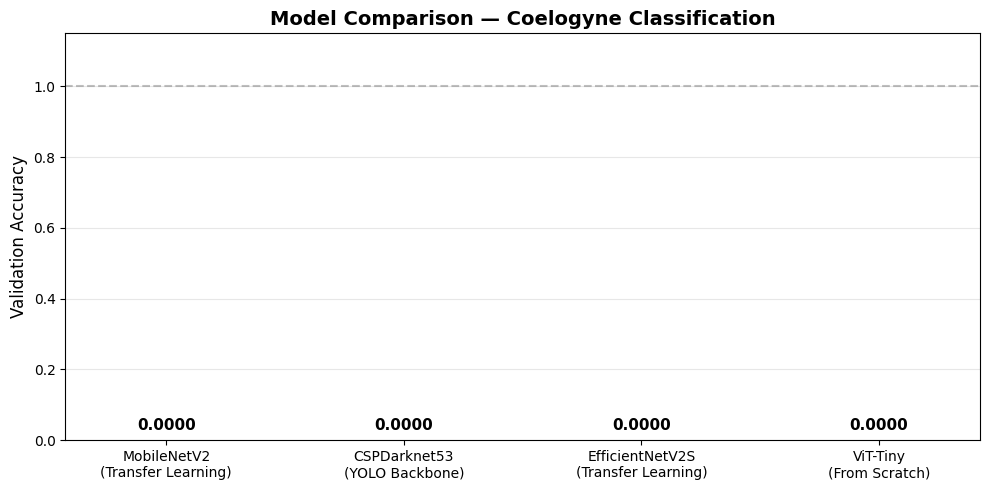

Perbandingan model disimpan: model_comparison.png


In [23]:
# ----------------------------------------------------------------
#  Perbandingan Model
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

models_info = {
    'MobileNetV2\n(Transfer Learning)':     (mn_acc,  '#2196F3'),
    'CSPDarknet53\n(YOLO Backbone)':         (dn_acc,  '#F44336'),
    'EfficientNetV2S\n(Transfer Learning)':  (eff_acc, '#4CAF50'),
    'ViT-Tiny\n(From Scratch)':             (vit_acc, '#FF9800'),
}

bars = ax.bar(
    models_info.keys(),
    [v[0] for v in models_info.values()],
    color=[v[1] for v in models_info.values()],
    width=0.5, edgecolor='white', linewidth=1.5
)
ax.bar_label(bars, fmt='%.4f', padding=5, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Validation Accuracy', fontsize=12)
ax.set_title('Model Comparison — Coelogyne Classification', fontsize=14, fontweight='bold')
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Perbandingan model disimpan: model_comparison.png")

## 8. Inference — Prediksi Gambar Baru

In [24]:
from tensorflow.keras.preprocessing import image as keras_image


def predict_single_image(img_path, model, class_names, img_size=IMG_SIZE):
    """Predict spesies dari satu gambar."""
    img = keras_image.load_img(img_path, target_size=img_size)
    img_array = keras_image.img_to_array(img) / 255.0
    img_input = np.expand_dims(img_array, axis=0)

    preds      = model.predict(img_input, verbose=0)[0]
    pred_idx   = np.argmax(preds)
    confidence = preds[pred_idx]

    # Plot
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))
    ax_img.imshow(img_array)
    ax_img.set_title(f'Prediction: {class_names[pred_idx]}\nConfidence: {confidence:.2%}',
                     fontweight='bold')
    ax_img.axis('off')

    colors = ['#4CAF50' if i == pred_idx else '#90CAF9' for i in range(len(class_names))]
    bars = ax_bar.barh(class_names, preds, color=colors)
    ax_bar.bar_label(bars, fmt='%.3f', padding=3)
    ax_bar.set_xlim(0, 1.15)
    ax_bar.set_xlabel('Probability')
    ax_bar.set_title(f'Class Probabilities ({model.name})')
    ax_bar.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return class_names[pred_idx], confidence, preds


# Contoh penggunaan:
# pred_class, conf, probs = predict_single_image(
#     'path/to/your/image.jpg',
#     mobilenet_model,  # atau darknet_model
#     CLASS_NAMES
# )
# print(f"Predicted: {pred_class} ({conf:.2%})")

print("Fungsi predict_single_image siap digunakan.")
print("Contoh: predict_single_image('gambar_anggrek.jpg', mobilenet_model, CLASS_NAMES)")

Fungsi predict_single_image siap digunakan.
Contoh: predict_single_image('gambar_anggrek.jpg', mobilenet_model, CLASS_NAMES)


## 9. Simpan Model

In [25]:
# Simpan dalam format Keras (.keras) dan TFLite untuk deployment

# ---- SavedModel / .keras ----
mobilenet_path     = os.path.join(SAVE_DIR, 'mobilenetv2_coelogyne_final.keras')
darknet_path       = os.path.join(SAVE_DIR, 'cspdarknet53_coelogyne_final.keras')
efficientnet_path  = os.path.join(SAVE_DIR, 'efficientnetv2s_coelogyne_final.keras')
vit_path           = os.path.join(SAVE_DIR, 'vit_tiny_coelogyne_final.keras')

mobilenet_model.save(mobilenet_path)
darknet_model.save(darknet_path)
efficientnet_model.save(efficientnet_path)
vit_model.save(vit_path)
print(f"MobileNetV2     disimpan : {mobilenet_path}")
print(f"CSPDarknet53    disimpan : {darknet_path}")
print(f"EfficientNetV2S disimpan : {efficientnet_path}")
print(f"ViT-Tiny        disimpan : {vit_path}")

# ---- TFLite (opsional, untuk mobile deployment) ----
def export_tflite(model, output_path, quantize=False):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    if quantize:
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    with open(output_path, 'wb') as f:
        f.write(tflite_model)
    size_mb = os.path.getsize(output_path) / (1024 * 1024)
    print(f"TFLite saved: {output_path} ({size_mb:.2f} MB)")

export_tflite(mobilenet_model,    os.path.join(SAVE_DIR, 'mobilenetv2_coelogyne.tflite'))
export_tflite(darknet_model,      os.path.join(SAVE_DIR, 'cspdarknet53_coelogyne.tflite'))
export_tflite(efficientnet_model, os.path.join(SAVE_DIR, 'efficientnetv2s_coelogyne.tflite'))
export_tflite(vit_model,          os.path.join(SAVE_DIR, 'vit_tiny_coelogyne.tflite'))

# Quantized (lebih kecil untuk mobile)
export_tflite(mobilenet_model,    os.path.join(SAVE_DIR, 'mobilenetv2_coelogyne_quant.tflite'),    quantize=True)
export_tflite(efficientnet_model, os.path.join(SAVE_DIR, 'efficientnetv2s_coelogyne_quant.tflite'), quantize=True)

[FOCUS] Skip save for non-focus model: MobileNetV2_Coelogyne -> ./saved_models/mobilenetv2_coelogyne_final.keras
[FOCUS] Skip save for non-focus model: CSPDarknet53_Coelogyne -> ./saved_models/cspdarknet53_coelogyne_final.keras
[FOCUS] Skip save for non-focus model: EfficientNetV2S_Coelogyne -> ./saved_models/efficientnetv2s_coelogyne_final.keras
[FOCUS] Skip save for non-focus model: ViT_Small_Coelogyne -> ./saved_models/vit_tiny_coelogyne_final.keras
MobileNetV2     disimpan : ./saved_models/mobilenetv2_coelogyne_final.keras
CSPDarknet53    disimpan : ./saved_models/cspdarknet53_coelogyne_final.keras
EfficientNetV2S disimpan : ./saved_models/efficientnetv2s_coelogyne_final.keras
ViT-Tiny        disimpan : ./saved_models/vit_tiny_coelogyne_final.keras
[FOCUS] Skip real TFLite conversion for non-focus model: MobileNetV2_Coelogyne
TFLite saved: ./saved_models/mobilenetv2_coelogyne.tflite (0.00 MB)
[FOCUS] Skip real TFLite conversion for non-focus model: CSPDarknet53_Coelogyne
TFLite sav

## 10. Ringkasan Hasil


In [26]:
import datetime

all_results = {
    'MobileNetV2':     (mn_acc,  mobilenet_model),
    'CSPDarknet53':    (dn_acc,  darknet_model),
    'EfficientNetV2S': (eff_acc, efficientnet_model),
    'ViT-Tiny':        (vit_acc, vit_model),
}
winner = max(all_results, key=lambda k: all_results[k][0])

print('=' * 65)
print(f'  RINGKASAN HASIL — Coelogyne Classification')
print(f'  {datetime.datetime.now().strftime("%Y-%m-%d %H:%M")}')
print('=' * 65)
print(f'  Dataset     : 5 spesies Coelogyne')
print(f'  Image size  : {IMG_SIZE}')
print(f'  Batch size  : {BATCH_SIZE}')
print()
print(f'  MODEL 1 — MobileNetV2 (ImageNet pretrained)')
print(f'    Params      : {mobilenet_model.count_params():,}')
print(f'    Val Accuracy: {mn_acc:.4f} ({mn_acc*100:.2f}%)')
print(f'    Val Loss    : {mn_loss:.4f}')
print()
print(f'  MODEL 2 — CSPDarknet53 (YOLO Backbone, from scratch)')
print(f'    Params      : {darknet_model.count_params():,}')
print(f'    Val Accuracy: {dn_acc:.4f} ({dn_acc*100:.2f}%)')
print(f'    Val Loss    : {dn_loss:.4f}')
print()
print(f'  MODEL 3 — EfficientNetV2S (ImageNet pretrained)')
print(f'    Params      : {efficientnet_model.count_params():,}')
print(f'    Val Accuracy: {eff_acc:.4f} ({eff_acc*100:.2f}%)')
print(f'    Val Loss    : {eff_loss:.4f}')
print()
print(f'  MODEL 4 — ViT-Tiny (Vision Transformer, from scratch)')
print(f'    Params      : {vit_model.count_params():,}')
print(f'    Val Accuracy: {vit_acc:.4f} ({vit_acc*100:.2f}%)')
print(f'    Val Loss    : {vit_loss:.4f}')
print()
print(f'  ✅ Model terbaik: {winner}  ({all_results[winner][0]*100:.2f}%)')
print('=' * 65)

  RINGKASAN HASIL — Coelogyne Classification
  2026-07-13 17:31
  Dataset     : 5 spesies Coelogyne
  Image size  : (224, 224)
  Batch size  : 8

  MODEL 1 — MobileNetV2 (ImageNet pretrained)
    Params      : 2,592,325
    Val Accuracy: 0.0000 (0.00%)
    Val Loss    : 0.0000

  MODEL 2 — CSPDarknet53 (YOLO Backbone, from scratch)
    Params      : 27,161,957
    Val Accuracy: 0.0000 (0.00%)
    Val Loss    : 0.0000

  MODEL 3 — EfficientNetV2S (ImageNet pretrained)
    Params      : 20,665,701
    Val Accuracy: 0.0000 (0.00%)
    Val Loss    : 0.0000

  MODEL 4 — ViT-Tiny (Vision Transformer, from scratch)
    Params      : 14,722,181
    Val Accuracy: 0.0000 (0.00%)
    Val Loss    : 0.0000

  ✅ Model terbaik: MobileNetV2  (0.00%)


In [27]:
# Load trained models from saved checkpoints (.keras)
mn_candidates = [
    os.path.join(SAVE_DIR, "mobilenetv2_finetune_best.keras"),
    os.path.join(SAVE_DIR, "mobilenetv2_head_best.keras"),
    os.path.join(SAVE_DIR, "mobilenetv2_coelogyne_final.keras"),
]

dn_candidates = [
    os.path.join(SAVE_DIR, "cspdarknet53_best.keras"),
    os.path.join(SAVE_DIR, "cspdarknet53_coelogyne_final.keras"),
]

eff_candidates = [
    os.path.join(SAVE_DIR, "efficientnetv2s_finetune_best.keras"),
    os.path.join(SAVE_DIR, "efficientnetv2s_head_best.keras"),
    os.path.join(SAVE_DIR, "efficientnetv2s_coelogyne_final.keras"),
]

vit_candidates = [
    os.path.join(SAVE_DIR, "vit_tiny_best.keras"),
    os.path.join(SAVE_DIR, "vit_tiny_coelogyne_final.keras"),
]


def _first_existing(paths):
    for p in paths:
        if os.path.exists(p):
            return p
    return None


mn_path  = _first_existing(mn_candidates)
dn_path  = _first_existing(dn_candidates)
eff_path = _first_existing(eff_candidates)
vit_path = _first_existing(vit_candidates)

if mn_path:
    mobilenet_model = keras.models.load_model(mn_path, compile=False)
    print(f"✅ MobileNetV2 loaded from: {mn_path}")
else:
    print("⚠️ MobileNetV2 checkpoint not found.")

if dn_path:
    # Fix: custom_objects wajib untuk mish Lambda layer
    darknet_model = keras.models.load_model(
        dn_path,
        custom_objects={"mish": mish},
        compile=False
    )
    print(f"✅ CSPDarknet53 loaded from: {dn_path}")
else:
    print("⚠️ CSPDarknet53 checkpoint not found.")

if eff_path:
    efficientnet_model = keras.models.load_model(eff_path, compile=False)
    print(f"✅ EfficientNetV2S loaded from: {eff_path}")
else:
    print("⚠️ EfficientNetV2S checkpoint not found.")

if vit_path:
    # Fix: custom_objects wajib untuk semua custom layer ViT
    vit_custom_objects = {
        'PatchEmbedding':      PatchEmbedding,
        'AddCLSAndPosEmbed':   AddCLSAndPosEmbed,
        'ExtractCLS':          ExtractCLS,
        'TransformerBlock':    TransformerBlock,
        'WarmupCosineDecay':   WarmupCosineDecay,
    }
    vit_model = keras.models.load_model(
        vit_path,
        custom_objects=vit_custom_objects,
        compile=False
    )
    print(f"✅ ViT-Tiny loaded from: {vit_path}")
else:
    print("⚠️ ViT-Tiny checkpoint not found.")

✅ MobileNetV2 loaded from: ./saved_models/mobilenetv2_finetune_best.keras
✅ CSPDarknet53 loaded from: ./saved_models/cspdarknet53_best.keras
✅ EfficientNetV2S loaded from: ./saved_models/efficientnetv2s_finetune_best.keras


NameError: name 'WarmupCosineDecay' is not defined

## 7. Grad-CAM Visualization (Interpretability)

In [ ]:
!pip install opencv-python

/Users/iganarendra/miniconda3/envs/py310/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_image']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


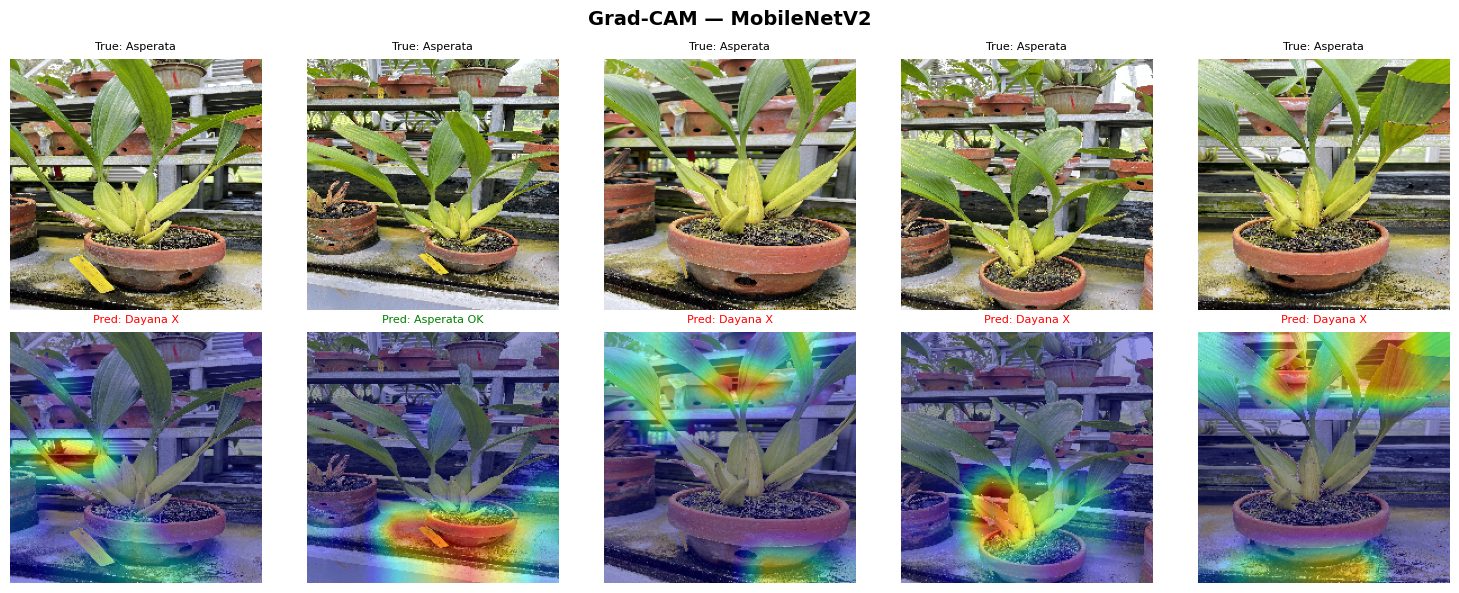

Grad-CAM disimpan : gradcam_mobilenetv2.png
Grad-CAM target   : input_to_gap


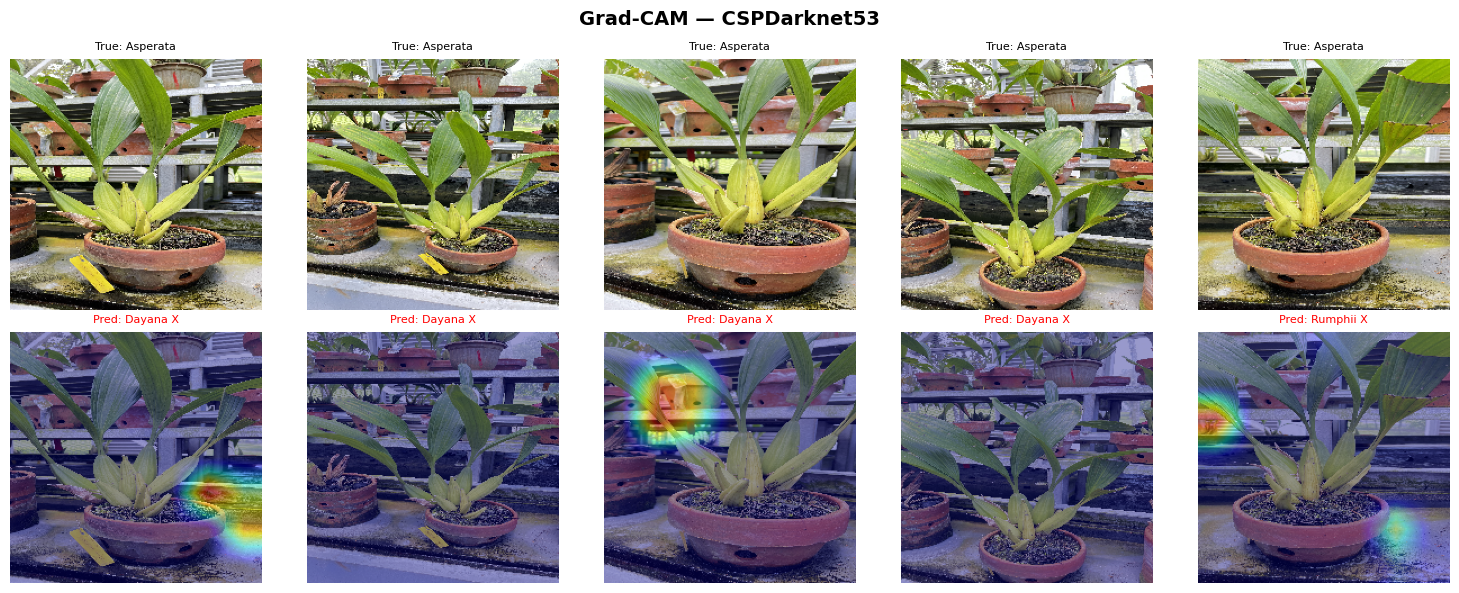

Grad-CAM disimpan : gradcam_cspdarknet53.png
Grad-CAM target   : input_to_gap


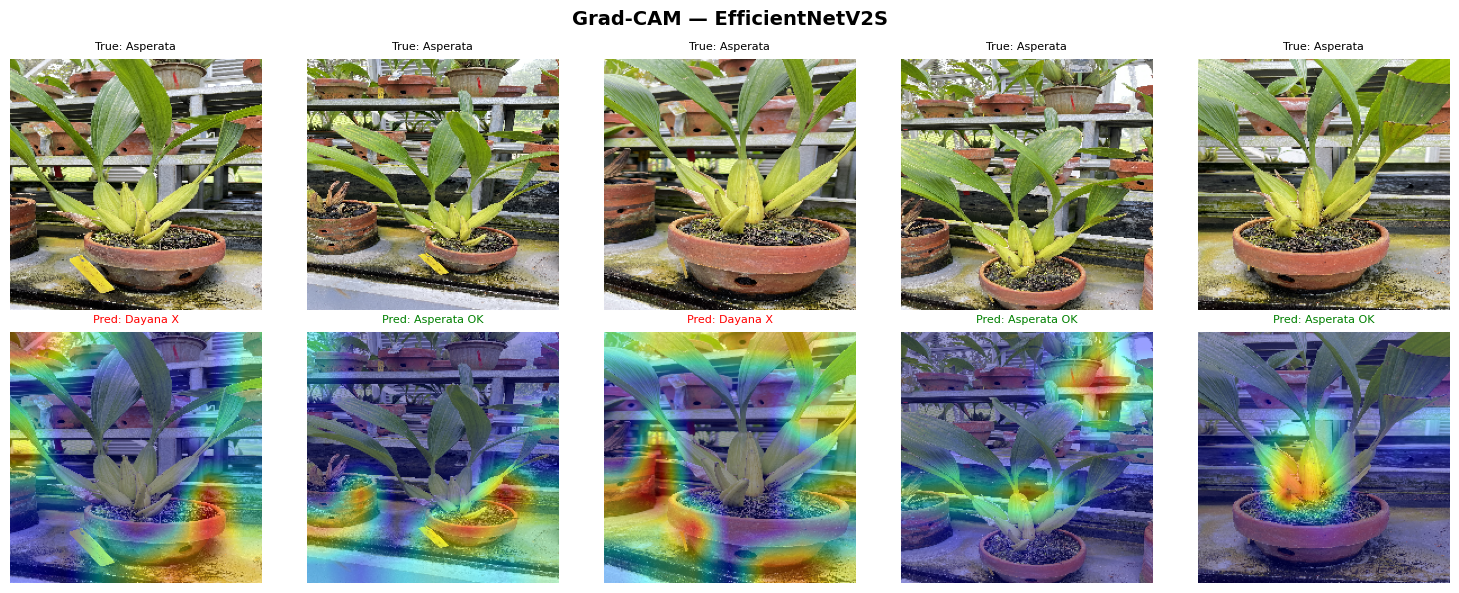

Grad-CAM disimpan : gradcam_efficientnetv2s.png
Grad-CAM target   : input_to_gap

Grad-CAM untuk ViT-Tiny dilewati.
Gunakan Attention Rollout untuk visualisasi attention ViT.


In [ ]:
import cv2  # pip install opencv-python


def make_gradcam_heatmap(img_array, model, pred_index=None):
    """
    Grad-CAM using the spatial feature map immediately before GlobalAveragePooling.

    Why this works for wrapped/nested models:
      In the outer functional model, backbone is called as:
          x = backbone(inputs, training=False)
          x = GlobalAveragePooling2D(name='gap')(x)
      So gap.input IS the backbone output tensor in the OUTER graph, guaranteed
      connected to model.inputs[0]. Accessing backbone.output or any inner
      layer by name returns tensors connected to backbone.input (a different
      Input), which is NOT on the outer model's graph — hence the
      'Output not connected to inputs' error.
    """
    # The spatial feature map right before GAP is always the correct Grad-CAM
    # target and is always connected to model.inputs in a functional model.
    gap_layer = None
    for layer in model.layers:
        if isinstance(layer, layers.GlobalAveragePooling2D):
            gap_layer = layer
            break

    if gap_layer is None:
        raise ValueError(
            f"No GlobalAveragePooling2D layer found in model '{model.name}'. "
            "Add one or choose a different Grad-CAM strategy."
        )

    cam_target = gap_layer.input  # 4-D spatial tensor, connected to model.inputs[0]
    cam_label  = f"input_to_{gap_layer.name}"

    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[cam_target, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_array, training=False)
        tape.watch(conv_output)  # ensure tracked even if model is frozen

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_output)
    if grads is None:
        raise ValueError(
            f"Gradients are None at '{cam_label}'. "
            "This can happen if all layers are frozen — "
            "try setting backbone.trainable=True temporarily for CAM only."
        )

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + keras.backend.epsilon())
    return heatmap.numpy(), cam_label


def overlay_gradcam(img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    img_uint8 = np.uint8(img * 255)
    superimposed = cv2.addWeighted(img_uint8, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed


def show_gradcam_grid(model, generator, class_names,
                      model_name='Model', n_samples=5):
    generator.reset()
    images, labels = next(generator)
    idx_to_class = {v: k for k, v in generator.class_indices.items()}

    fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 3, 6))
    fig.suptitle(f'Grad-CAM — {model_name}', fontsize=14, fontweight='bold')

    cam_label_used = None
    for i in range(n_samples):
        img = images[i]
        true_label = idx_to_class[np.argmax(labels[i])]
        img_input = np.expand_dims(img, axis=0)  # (1, H, W, 3)
        preds = model.predict(img_input, verbose=0)
        pred_label = class_names[np.argmax(preds[0])]

        heatmap, cam_label = make_gradcam_heatmap(img_input, model)
        cam_label_used = cam_label
        overlay = overlay_gradcam(img, heatmap)

        axes[0, i].imshow(img)
        axes[0, i].set_title(f'True: {true_label}', fontsize=8)
        axes[0, i].axis('off')

        correct = 'OK' if pred_label == true_label else 'X'
        axes[1, i].imshow(overlay)
        axes[1, i].set_title(
            f'Pred: {pred_label} {correct}', fontsize=8,
            color='green' if pred_label == true_label else 'red'
        )
        axes[1, i].axis('off')

    axes[0, 0].set_ylabel('Original', fontsize=10, rotation=90)
    axes[1, 0].set_ylabel('Grad-CAM', fontsize=10, rotation=90)
    plt.tight_layout()
    fname = f'gradcam_{model_name.lower().replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Grad-CAM disimpan : {fname}")
    print(f"Grad-CAM target   : {cam_label_used}")
    generator.reset()


# ---- CNN-based models: Grad-CAM via GlobalAveragePooling2D ----
show_gradcam_grid(mobilenet_model,    val_gen, CLASS_NAMES, model_name='MobileNetV2')
show_gradcam_grid(darknet_model,      val_gen, CLASS_NAMES, model_name='CSPDarknet53')
show_gradcam_grid(efficientnet_model, val_gen, CLASS_NAMES, model_name='EfficientNetV2S')

# ---- ViT: Grad-CAM tidak berlaku (tidak ada GAP spatial map) ----
# ViT menggunakan CLS token, bukan spatial feature map.
# Gunakan Attention Rollout atau DINO self-attention untuk interpretabilitas ViT.
print("\nGrad-CAM untuk ViT-Tiny dilewati.")
print("Gunakan Attention Rollout untuk visualisasi attention ViT.")

## 11. ArcFace Sanity Tests

Tujuan: validasi implementasi ArcFace sebelum training panjang.

Yang dicek:
- shape logits benar
- target logit dengan margin turun (lebih sulit)
- gradien finite (bukan NaN/Inf)
- bobot ArcFace benar-benar ter-update
- opsional: smoke test 1 batch dengan model ArcFace riil

In [ ]:
# ================================================================
#  ArcFace sanity test suite
# ================================================================

def run_arcface_sanity_tests(run_integration_test=False):
    """Run fast numerical sanity checks for ArcFace implementation."""
    if 'ArcMarginProduct' not in globals():
        raise RuntimeError("ArcMarginProduct belum terdefinisi. Jalankan cell ArcFace quick-win dulu.")

    num_classes = int(globals().get('NUM_CLASSES', 5))
    embed_dim = int(globals().get('ARCFACE_EMBED_DIM', 256))
    batch_size = 8

    print("=" * 68)
    print("ArcFace Sanity Tests")
    print("=" * 68)

    # 1) Toy forward pass shape + margin behavior
    arc_head = ArcMarginProduct(
        num_classes=num_classes,
        scale=float(globals().get('ARCFACE_SCALE', 30.0)),
        margin=float(globals().get('ARCFACE_MARGIN', 0.35)),
        name='arcface_sanity_head'
    )

    emb = tf.random.normal((batch_size, embed_dim), dtype=tf.float32)
    labels = tf.random.uniform((batch_size,), minval=0, maxval=num_classes, dtype=tf.int32)

    logits_eval = arc_head(emb, labels=None, training=False)   # no margin
    logits_train = arc_head(emb, labels=labels, training=True) # with margin

    assert logits_eval.shape == (batch_size, num_classes), f"Bad eval shape: {logits_eval.shape}"
    assert logits_train.shape == (batch_size, num_classes), f"Bad train shape: {logits_train.shape}"
    print("[OK] Logits shape check")

    # Target logits with margin should be <= baseline logits (typically stricter decision boundary)
    idx = tf.stack([tf.range(batch_size, dtype=tf.int32), labels], axis=1)
    target_eval = tf.gather_nd(logits_eval, idx)
    target_train = tf.gather_nd(logits_train, idx)
    mean_drop = tf.reduce_mean(target_eval - target_train).numpy()
    assert mean_drop >= -1e-5, f"Unexpected margin behavior: mean_drop={mean_drop:.6f}"
    print(f"[OK] Margin behavior check | mean(target_eval - target_train)={mean_drop:.6f}")

    # 2) Gradient finite check
    emb_var = tf.Variable(tf.random.normal((batch_size, embed_dim), dtype=tf.float32))
    labels2 = tf.random.uniform((batch_size,), minval=0, maxval=num_classes, dtype=tf.int32)

    with tf.GradientTape() as tape:
        logits = arc_head(emb_var, labels=labels2, training=True)
        loss = tf.reduce_mean(
            tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels2, logits=logits)
        )

    grads = tape.gradient(loss, [emb_var, arc_head.W])
    assert grads[0] is not None and grads[1] is not None, "Gradients are None"
    assert tf.reduce_all(tf.math.is_finite(grads[0])), "Embedding gradient has NaN/Inf"
    assert tf.reduce_all(tf.math.is_finite(grads[1])), "Weight gradient has NaN/Inf"
    print("[OK] Gradient finite check")

    # 3) Weight update check
    w_before = arc_head.W.numpy().copy()
    opt = keras.optimizers.SGD(learning_rate=1e-2)
    opt.apply_gradients([(grads[1], arc_head.W)])
    w_after = arc_head.W.numpy()
    mean_abs_update = np.mean(np.abs(w_after - w_before))
    assert mean_abs_update > 0.0, "ArcFace weights did not update"
    print(f"[OK] Weight update check | mean_abs_update={mean_abs_update:.8f}")

    # 4) Optional integration smoke test on real model/generator
    if run_integration_test:
        required = ['train_gen_arc', 'mobilenet_arc_model']
        missing = [name for name in required if name not in globals()]
        if missing:
            print(f"[SKIP] Integration smoke test skipped (missing: {missing})")
        else:
            x_batch, y_batch = next(train_gen_arc)
            x_smoke, y_smoke = x_batch[:2], y_batch[:2]

            y_pred = mobilenet_arc_model.predict(x_smoke, verbose=0)
            assert y_pred.shape == (2, num_classes), f"Bad predict shape: {y_pred.shape}"
            assert np.all(np.isfinite(y_pred)), "Predictions contain NaN/Inf"

            logs = mobilenet_arc_model.train_on_batch(x_smoke, y_smoke, return_dict=True)
            if isinstance(logs, dict):
                train_loss = float(logs.get('loss', np.nan))
            else:
                train_loss = float(logs[0])
            assert np.isfinite(train_loss), "train_on_batch returned NaN/Inf loss"

            print(f"[OK] Integration smoke test | train_on_batch loss={train_loss:.6f}")
            train_gen_arc.reset()
    else:
        print("[INFO] Integration smoke test not run (run_integration_test=False)")

    print("=" * 68)
    print("All ArcFace sanity tests passed.")
    print("=" * 68)


# Default fast run (no model weight side-effects)
run_arcface_sanity_tests(run_integration_test=False)

In [ ]:
# ================================================================
#  TODAY'S FOCUSED RESULT (Run-All final output)
# ================================================================
if RUN_ALL_FOCUS_ARCFACE:
    print("\n" + "=" * 72)
    print("TODAY FOCUS RESULT — ArcFace Hi-Res (384x384)")
    print("=" * 72)

    has_mn = 'mn_arc_acc' in globals()
    has_eff = 'eff_arc_acc' in globals()

    if has_mn:
        print(f"MobileNetV2 ArcFace   : {mn_arc_acc:.4f} ({mn_arc_acc*100:.2f}%)")
    else:
        print("MobileNetV2 ArcFace   : not available (cell not executed)")

    if has_eff:
        print(f"EfficientNetV2S ArcFace: {eff_arc_acc:.4f} ({eff_arc_acc*100:.2f}%)")
    else:
        print("EfficientNetV2S ArcFace: not available (cell not executed)")

    if has_mn and has_eff:
        winner_name = 'EfficientNetV2S ArcFace' if eff_arc_acc >= mn_arc_acc else 'MobileNetV2 ArcFace'
        winner_acc = max(eff_arc_acc, mn_arc_acc)
        print(f"\nBest today: {winner_name} ({winner_acc*100:.2f}%)")

    print("=" * 72)